# Predicting 30-day hospital readmission among patients with diabetes

## Business and data-science problem

At the time of discharge, hospitals need to identify patients with diabetes who are at elevated risk of readmission within 30 days so that limited transition-of-care resources can be targeted appropriately.

This is a **supervised binary-classification** task. The positive class is readmission within 30 days (`readmitted == "<30"`); readmission after 30 days and no recorded readmission form the negative class.

**Prediction time:** discharge from the index encounter. Consequently, only information available by discharge is eligible. This includes length of stay, discharge disposition, diagnoses recorded during the encounter, laboratory-test status, and medication changes. The model is predictive rather than causal.

**Primary model metric:** area under the precision–recall curve (PR-AUC), selected because the positive class is uncommon. Secondary metrics are ROC-AUC, recall, precision, F1, specificity, Brier score, and calibration. Accuracy is reported only as a reference and is not used as the main selection criterion.

**Operational KPI:** readmissions identified per 100 patients offered an intervention, evaluated alongside the intervention capacity, estimated preventable readmissions, and net savings after intervention costs.


In [1]:
import pandas as pd
import numpy as np
diabetic = pd.read_csv("diabetic_data.csv", keep_default_na=False)
diabetic = diabetic.replace("?", np.nan)

## Data source and data dictionary

**Source:** UCI Machine Learning Repository, *Diabetes 130-US Hospitals for Years 1999–2008*. Each row represents one inpatient diabetes encounter. The outcome supplied by the dataset is `readmitted`, with values `<30`, `>30`, and `NO`.

| Variable(s) | Type | Meaning / units | Principal values |
|---|---|---|---|
| `encounter_id`, `patient_nbr` | Identifier | Encounter and patient identifiers | Positive integers |
| `race`, `gender`, `age`, `weight` | Categorical | Patient demographics; age and weight are bands | Dataset-defined labels; `?` denotes unavailable data |
| `admission_type_id` | Categorical code | Admission type | Integer codes defined by UCI mapping |
| `discharge_disposition_id` | Categorical code | Discharge destination/status | Integer codes defined by UCI mapping |
| `admission_source_id` | Categorical code | Referral/admission source | Integer codes defined by UCI mapping |
| `time_in_hospital` | Integer | Length of stay in days | 1–14 |
| `payer_code`, `medical_specialty` | Categorical | Payer and admitting specialty | Dataset-defined labels |
| `num_lab_procedures` | Integer count | Laboratory procedures during encounter | Non-negative count |
| `num_procedures` | Integer count | Non-laboratory procedures | Non-negative count |
| `num_medications` | Integer count | Distinct generic medication names | Positive count |
| `number_outpatient` | Integer count | Outpatient visits in preceding year | Non-negative count |
| `number_emergency` | Integer count | Emergency visits in preceding year | Non-negative count |
| `number_inpatient` | Integer count | Inpatient visits in preceding year | Non-negative count |
| `diag_1`, `diag_2`, `diag_3` | Categorical code | Primary and secondary ICD-9 diagnoses | ICD-9 code or unavailable |
| `number_diagnoses` | Integer count | Diagnoses entered in the system | Positive count |
| `max_glu_serum` | Categorical | Maximum serum glucose result | `Norm`, `>200`, `>300`, `Not_measured` |
| `A1Cresult` | Categorical | HbA1c test result | `Norm`, `>7`, `>8`, `Not_measured` |
| Medication columns | Ordinal categorical | Status for each diabetes drug | `No`, `Steady`, `Up`, `Down` |
| `change` | Binary categorical | Any change in diabetes medication | `Ch`, `No` |
| `diabetesMed` | Binary categorical | Any diabetes medication prescribed | `Yes`, `No` |
| `readmitted` | Target | Time to subsequent readmission | `<30`, `>30`, `NO` |

The complete descriptions and ID-code mappings should also be retained in the repository documentation and attributed to the UCI source.


In [2]:
diabetic.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [3]:
#INITIAL DATA QUALITY AND COHORT INTEGRITY CHECKS

print("Original encounters:", len(diabetic))

print("Fully duplicated rows:", diabetic.duplicated().sum())

print("Unique encounter IDs:", diabetic["encounter_id"].nunique())

print("Duplicated encounter IDs:", diabetic["encounter_id"].duplicated().sum())

print("Unique patients:", diabetic["patient_nbr"].nunique())

print("Additional encounters from repeat patients:", diabetic["patient_nbr"].duplicated().sum())

Original encounters: 101766
Fully duplicated rows: 0
Unique encounter IDs: 101766
Duplicated encounter IDs: 0
Unique patients: 71518
Additional encounters from repeat patients: 30248


In [4]:
#CATEGORICAL VARIABLE SUMMARY

categorical_summary = pd.DataFrame({
    "Data_Type": diabetic.select_dtypes(
        include=["object", "category"]
    ).dtypes.astype(str),

    "Unique_Values": diabetic.select_dtypes(
        include=["object", "category"]
    ).nunique(),

    "Missing_Count": diabetic.select_dtypes(
        include=["object", "category"]
    ).isna().sum(),

    "Missing_Percent": (
        diabetic.select_dtypes(
            include=["object", "category"]
        )
        .isna()
        .mean()
        .mul(100)
    )
})

categorical_summary.sort_values("Unique_Values", ascending=False)

,Data_Type,Unique_Values,Missing_Count,Missing_Percent
diag_3,object,789,1423,1.398306
diag_2,object,748,358,0.351787
diag_1,object,716,21,0.020636
medical_specialty,object,72,49949,49.082208
payer_code,object,17,40256,39.557416
age,object,10,0,0.000000
weight,object,9,98569,96.858479
race,object,5,2273,2.233555
glyburide-metformin,object,4,0,0.000000
max_glu_serum,object,4,0,0.000000


### Interpreting laboratory-test missingness
`A1Cresult` is especially important in this dataset. The original Strack et al. paper was specifically about HbA1c measurement and readmission, 
and the variable is defined as >8, >7, Norm, or `None` if the test was not measured. Importantly, "None" here is not ordinary missing data. 
It means the HbA1c test was not performed, which itself may carry useful information. This is informative absence rather than an accidentally lost observation.This label is therefore converted explicitly to `Not_measured` and retained as valid categories. 

The same applies to `max_glu_serum`. Its categories represent Norm, >200, >300, and `None` when no test was performed. So again, "None" is meaningful,
it means “serum glucose test not performed”, not “we lost the data”.

This distinction is clinically important: whether a test was ordered or recorded may itself contain predictive information.

In [5]:
# In these two variables, "None" means that the test was not performed.
for laboratory_feature in ["A1Cresult", "max_glu_serum"]:
    diabetic[laboratory_feature] = diabetic[laboratory_feature].replace(
        "None", "Not_measured"
    )

In [6]:
for col in ["race", "gender", "age", "max_glu_serum", "A1Cresult", "readmitted", "weight"]:
    print(f"\n--- {col} ---")
    print(diabetic[col].value_counts(dropna=False))


--- race ---
race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

--- gender ---
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

--- age ---
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

--- max_glu_serum ---
max_glu_serum
Not_measured    96420
Norm             2597
>200             1485
>300             1264
Name: count, dtype: int64

--- A1Cresult ---
A1Cresult
Not_measured    84748
>8               8216
Norm             4990
>7               3812
Name: count, dtype: int64

--- readmitted ---
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

--- weight ---
weight
NaN          98569
[75-100)      1336
[50-75)

## Cohort definition and domain-derived features

In [7]:
#STAGE 1 : DEFINING DATASET AND FINALIZING COHORT TO BE USED BEFORE SPLITTING DATA

#Step 1.1 - remove same patient with duplicate encounters - use only their first encounter (then have only 1 patient per encounter)
diabetic_cleandf = diabetic.copy()
diabetic_cleandf = diabetic_cleandf.sort_values("encounter_id").drop_duplicates("patient_nbr", keep="first")

#Step 1.2 - remove encounters that ended in death based on discharge_disposition_id
hospice_or_death_ids = {11, 13, 14, 19, 20, 21}
diabetic_cleandf = diabetic_cleandf[~diabetic_cleandf['discharge_disposition_id'].isin(hospice_or_death_ids)]
#Encounters ending in death or hospice disposition were excluded because subsequent hospital readmission is not an equivalent or 
#clinically meaningful outcome for these patients.

#Step 1.3 - remove patient_nbr (identifier), payer_code (irrelevant)
diabetic_cleandf = diabetic_cleandf.drop(["encounter_id", "patient_nbr", "payer_code"], axis=1)


In [8]:
diabetic_cleandf.shape #so now we're working with 69,973 with 46 features and 1 target

(69973, 47)

In [9]:
#Step 1.5: ICD-9 diagnosis group - using published ICD-9 mapping to group diagnoses (diag_1, diag_2, diag_3)

def group_diagnosis(icd_code):
    if pd.isna(icd_code):
        return "Unknown"
        
    if str(icd_code).startswith(("V", "E")): #if V and E codes dont fit the numeric ranges
        return "Other"

    try: #"try": attempt this code and if a specific error happens, this is how to handle it
        icd_code = float(icd_code) #float forces the code into decimal form. if conversion works, continue normally
    except ValueError: #e.g. V57 would raise a value-error and continue instead of program stopping
        return "Other"

    if 390<= icd_code <=459 or icd_code ==785:
        return "Circulatory"

    if 460<= icd_code <=519 or icd_code == 786:
        return "Respiratory"

    if 520<= icd_code <=579 or icd_code== 787:
        return "Digestive"

    if 250 <=icd_code <251 :
        return "Diabetes" #All 250.xx is Diabetes

    if 800<= icd_code <=999 :
        return "Injury"

    if 710<= icd_code <=739:
        return "Musculoskeletal"

    if 580<= icd_code <= 629 or icd_code == 788 :
        return "Genitourinary"

    if 140<= icd_code<=239 :
        return "Neoplasms"

    else :
        return "Other"
        
for col in ["diag_1", "diag_2", "diag_3"]:
    diabetic_cleandf[col + "_group"] = diabetic_cleandf[col].apply(group_diagnosis)

    
diabetic_cleandf = diabetic_cleandf.drop(["diag_1", "diag_2", "diag_3"], axis = 1) #drop original colums


In [10]:
#Step 1.6.: Keep major "medical_Specialty" groups and collapse others into "Other"
major_groups = ["Cardiology", "Family/GeneralPractice", "InternalMedicine", "Surgery-General"]

def specialty_groups(specialty):
    if pd.isna(specialty):
        return "Unknown"
    elif specialty in major_groups:
        return specialty
    else:
        return "Other"

diabetic_cleandf["medical_specialty"] = (diabetic_cleandf["medical_specialty"].apply(specialty_groups))


In [11]:
#Step 1.7. Add two more columns - "sumtotal_diabetes_meds" and "num_med_changes"

drug_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide','pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']

diabetic_cleandf["sumtotal_diabetes_meds"] = (diabetic_cleandf[drug_cols].isin(["Steady", "Up", "Down"]).sum(axis=1))
                
diabetic_cleandf["num_med_changes"]= (diabetic_cleandf[drug_cols].isin(["Up", "Down"])).sum(axis=1)
#"change" only tells you if some change happened or not, now we know how MANY changes were done
#It counts how many individual diabetes-medication columns have a dosage status of Up or Down for an encounter.

In [12]:
n_predictors = diabetic_cleandf.shape[1] - 1

print(
    f"The final cohort has {diabetic_cleandf.shape[0]:,} rows, "
    f"{n_predictors} predictors, and 1 target."
)

print("\nClass balance:")
display(
    diabetic_cleandf["readmitted"]
    .value_counts()
    .to_frame("observations")
)

The final cohort has 69,973 rows, 48 predictors, and 1 target.

Class balance:


,observations
readmitted,
NO,41474
>30,22222
<30,6277


## Target definition and train–test split

The source outcome is converted to a binary endpoint: `<30` is positive, while `>30` and `NO` are negative. A stratified 80/20 split preserves outcome prevalence. The test partition is reserved for final evaluation and is not used to choose transformations or features.


In [13]:
#STAGE 2 : TRAIN-TEST SPLIT AND EDA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

#Step 2.1 : Define Target
X= diabetic_cleandf.drop("readmitted", axis=1)
y= diabetic_cleandf["readmitted"].map({"<30":1, ">30" : 0, "NO" : 0})

assert y.notna().all(), "Unexpected value found in readmitted."
assert set(y.unique()) == {0, 1}

print(f"Re-admitted within 30 days (1-yes, 0-No): {y.value_counts(dropna=False)}")


Re-admitted within 30 days (1-yes, 0-No): readmitted
0    63696
1     6277
Name: count, dtype: int64


In [14]:
#Step 2.2 : Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

weight                      96.073457
race                         2.776091
gender                       0.000000
age                          0.000000
admission_type_id            0.000000
discharge_disposition_id     0.000000
admission_source_id          0.000000
time_in_hospital             0.000000
medical_specialty            0.000000
num_lab_procedures           0.000000
num_procedures               0.000000
num_medications              0.000000
number_outpatient            0.000000
number_emergency             0.000000
number_inpatient             0.000000
number_diagnoses             0.000000
max_glu_serum                0.000000
A1Cresult                    0.000000
metformin                    0.000000
repaglinide                  0.000000
nateglinide                  0.000000
chlorpropamide               0.000000
glimepiride                  0.000000
acetohexamide                0.000000
glipizide                    0.000000
glyburide                    0.000000
tolbutamide 

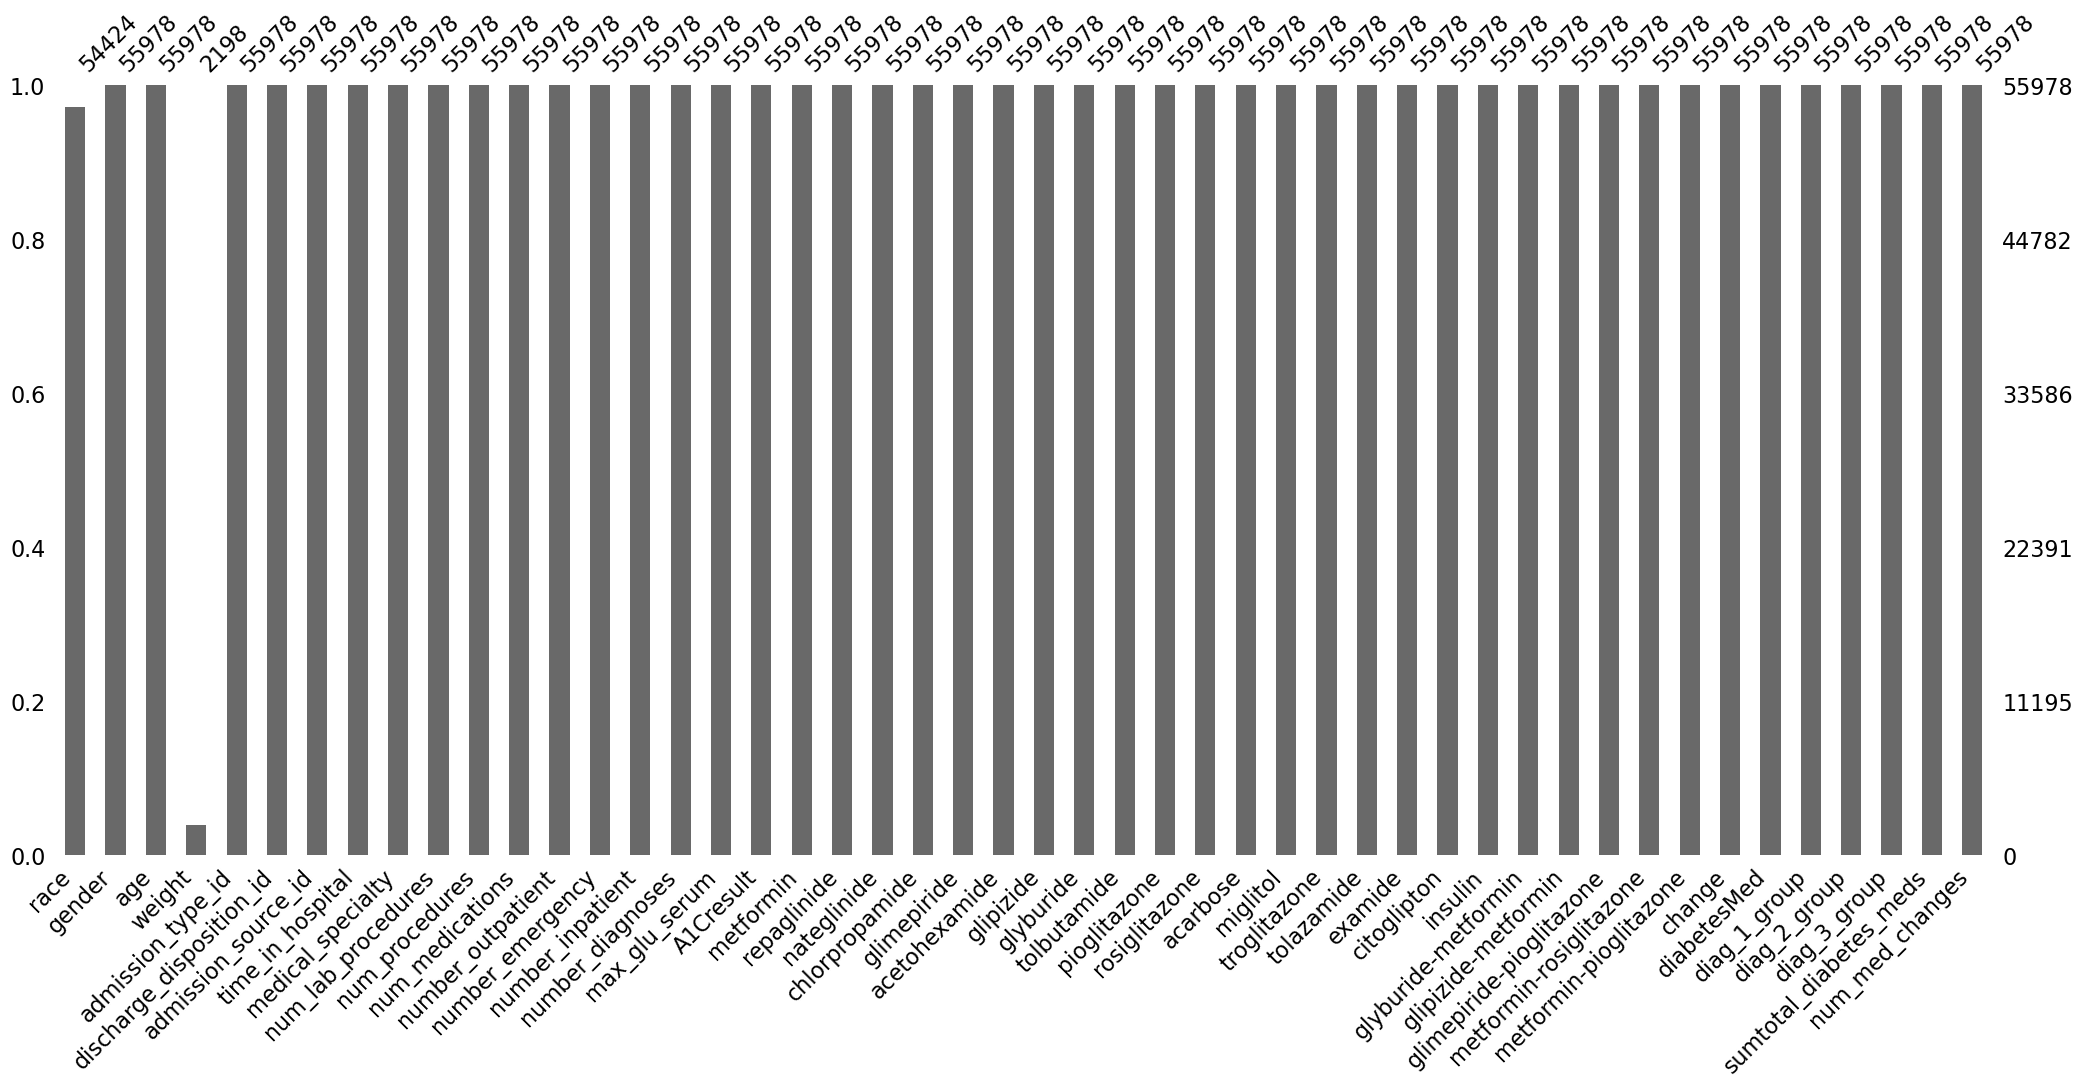

In [15]:
#Step 2.3. EDA on X_train

#Step2.3.1 : Missingness of Data
import missingno as msno
msno.bar(X_train)

missing_pct = (X_train.isnull().mean().mul(100).sort_values(ascending=False))
missing_pct


In [16]:
#Step 2.3.2 : Looking for low variance drugs

for col in drug_cols:
    print(X_train[col].value_counts(normalize=True, dropna=False).mul(100).round(2).sort_values())

metformin
Down       0.62
Up         1.19
Steady    19.52
No        78.67
Name: proportion, dtype: float64
repaglinide
Down       0.04
Up         0.11
Steady     1.18
No        98.68
Name: proportion, dtype: float64
nateglinide
Down       0.01
Up         0.02
Steady     0.66
No        99.31
Name: proportion, dtype: float64
chlorpropamide
Down       0.00
Up         0.01
Steady     0.09
No        99.90
Name: proportion, dtype: float64
glimepiride
Down       0.19
Up         0.34
Steady     4.74
No        94.73
Name: proportion, dtype: float64
acetohexamide
Steady      0.0
No        100.0
Name: proportion, dtype: float64
glipizide
Down       0.54
Up         0.82
Steady    11.56
No        87.08
Name: proportion, dtype: float64
glyburide
Down       0.59
Up         0.88
Steady     9.50
No        89.03
Name: proportion, dtype: float64
tolbutamide
Steady     0.02
No        99.98
Name: proportion, dtype: float64
pioglitazone
Down       0.12
Up         0.25
Steady     7.07
No        92.56
Name: p

In [17]:
#Conclusions from missingness analyses and low variance drugs
#To drop: examide, citoglipton and glimepiride-pioglitazone because of zero variance, and weight because of extreme missingness
X_train = X_train.drop(["weight", "examide", "citoglipton", "glimepiride-pioglitazone"], axis=1)
X_test = X_test.drop(["weight", "examide", "citoglipton", "glimepiride-pioglitazone"], axis=1)

## Training-only exploratory data analysis


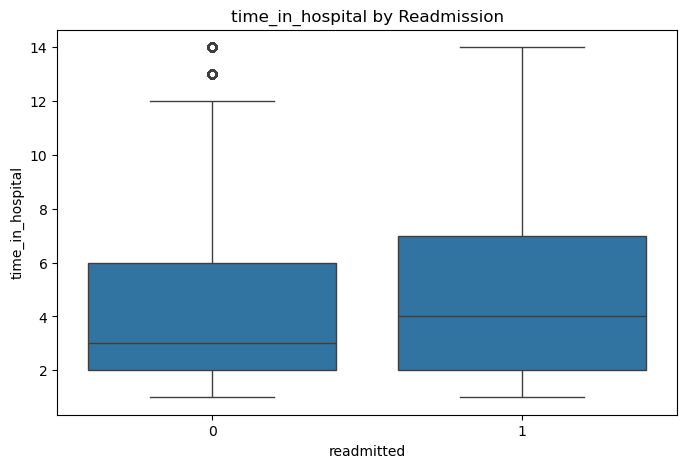

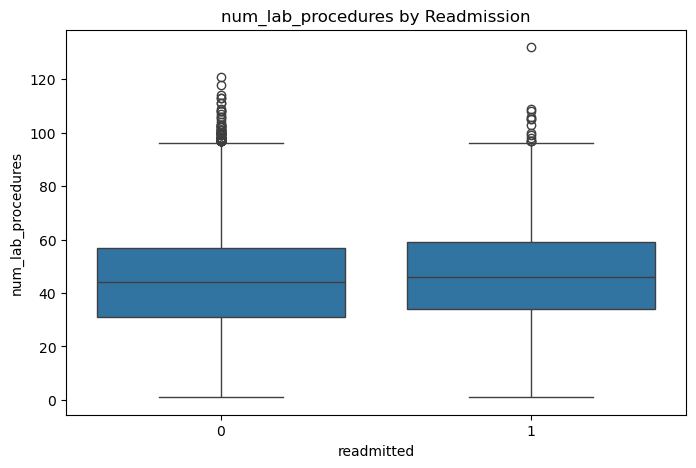

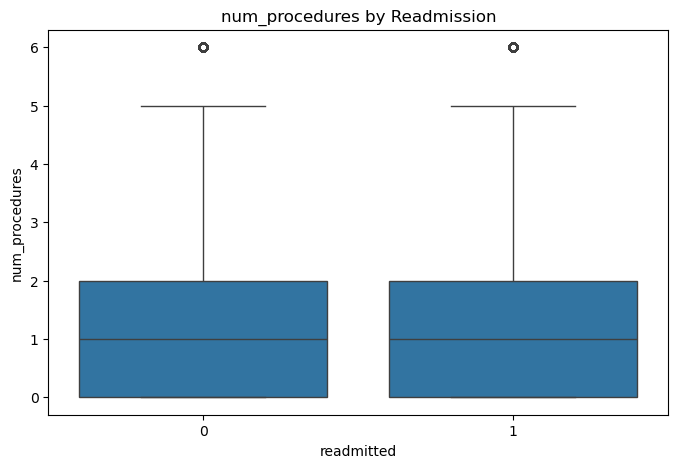

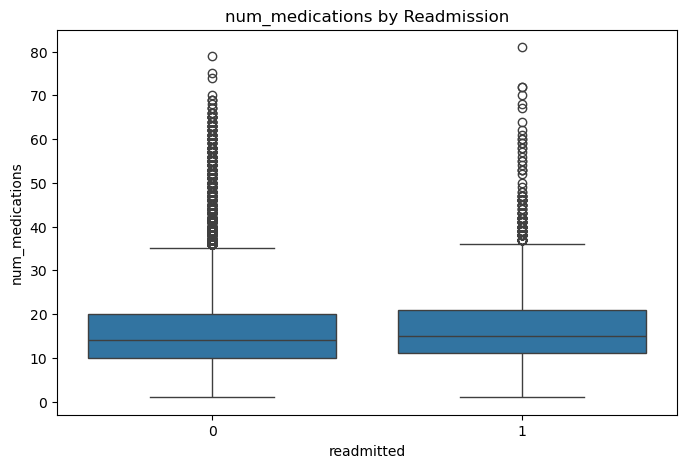

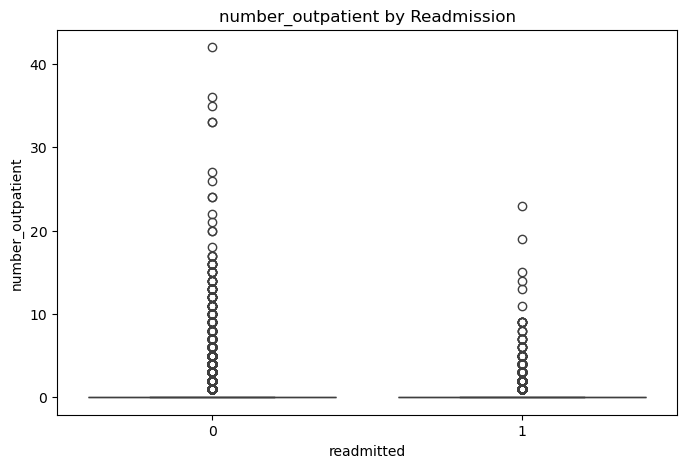

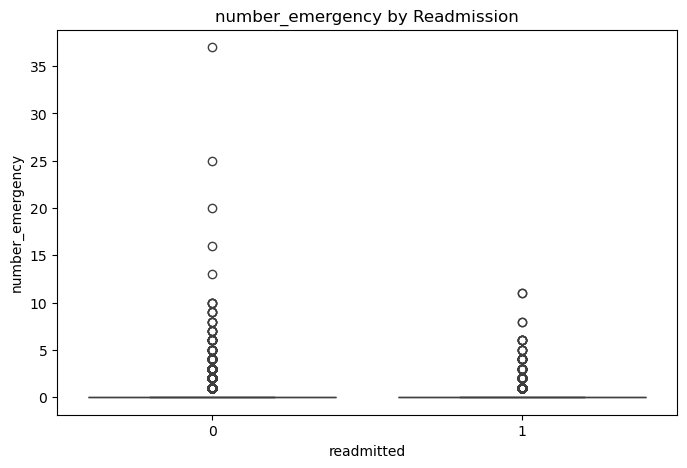

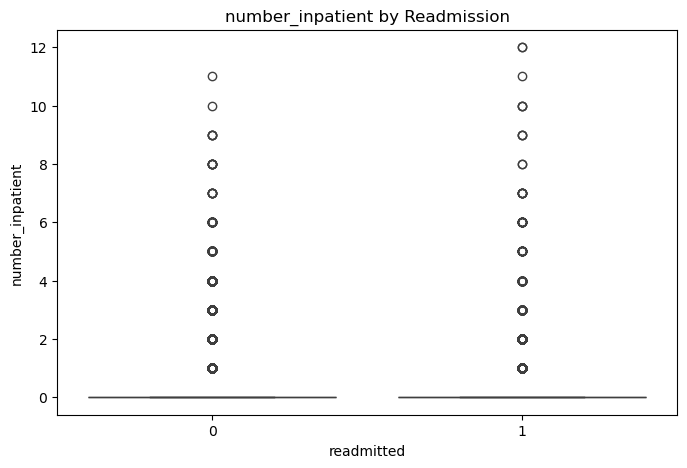

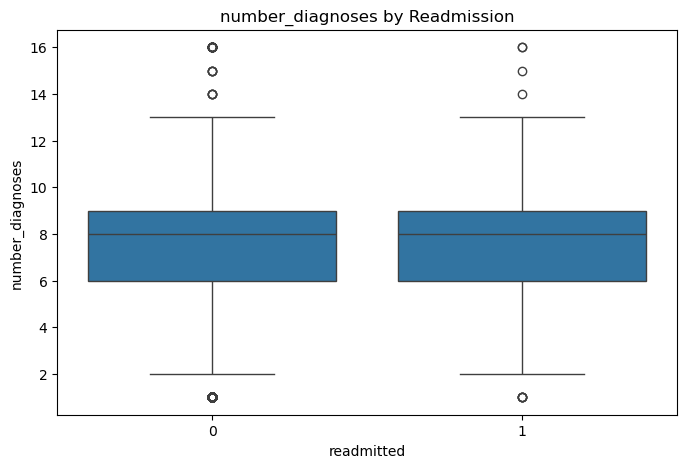

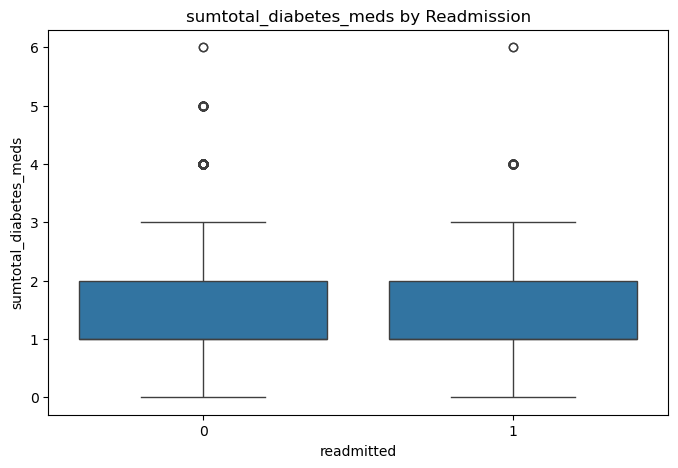

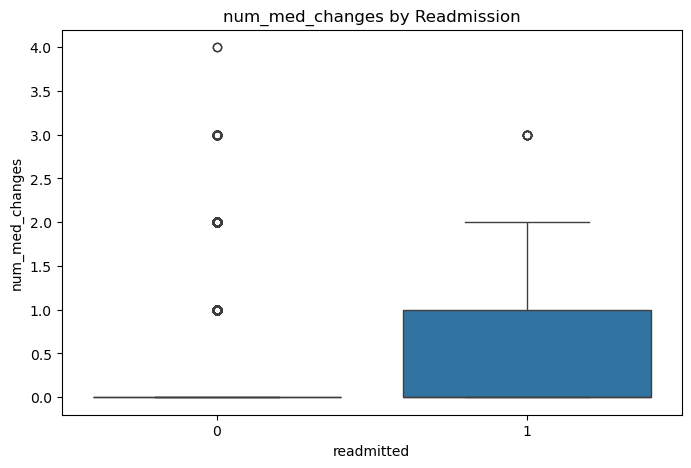

In [18]:
#STAGE 3 : EDA FOR UNDERSTANDING  DISTRIBUTIONS, RELATIONSHIPS, CLUSTERING TENDENCIES (Exploratory Data analysis for model-development)

#Step 3.1: NUMERICAL COLS
#Step 3.1.1: Boxplots to understand distributions of num cols by outcome
import seaborn as sns
import matplotlib.pyplot as plt

train_df = X_train.copy() #making a temporary combined df with training X_train + y_train
train_df["readmitted"] = y_train

numeric_cols = ["time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications", "number_outpatient",
                "number_emergency", "number_inpatient", "number_diagnoses", "sumtotal_diabetes_meds", "num_med_changes"]

for num in numeric_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(x="readmitted", y=num, data=train_df)
    plt.title(f"{num} by Readmission")
    plt.show()

In [19]:
#Step 3.1.2: Median & IQR to understand distributions of num cols by outcome
for col in numeric_cols:
    summary = (train_df.groupby("readmitted")[col].agg(median="median", Q1=lambda x: x.quantile(0.25), Q3=lambda x: x.quantile(0.75)))
    summary["IQR"] = summary["Q3"] - summary["Q1"]
    print(f"\n--- {col} ---")
    print(summary.round(2))


--- time_in_hospital ---
            median   Q1   Q3  IQR
readmitted                       
0              3.0  2.0  6.0  4.0
1              4.0  2.0  7.0  5.0

--- num_lab_procedures ---
            median    Q1    Q3   IQR
readmitted                          
0             44.0  31.0  57.0  26.0
1             46.0  34.0  59.0  25.0

--- num_procedures ---
            median   Q1   Q3  IQR
readmitted                       
0              1.0  0.0  2.0  2.0
1              1.0  0.0  2.0  2.0

--- num_medications ---
            median    Q1    Q3   IQR
readmitted                          
0             14.0  10.0  20.0  10.0
1             15.0  11.0  21.0  10.0

--- number_outpatient ---
            median   Q1   Q3  IQR
readmitted                       
0              0.0  0.0  0.0  0.0
1              0.0  0.0  0.0  0.0

--- number_emergency ---
            median   Q1   Q3  IQR
readmitted                       
0              0.0  0.0  0.0  0.0
1              0.0  0.0  0.0  0.0

---

In [20]:
#Step 3.1.2:Looking closely at the zero-sparse features from Median/IQR table: how common each value is in %, sorted 
for col in ["number_outpatient", "number_emergency", "number_inpatient", "num_med_changes"]:
    print(f"\n--- {col} ---")
    print(train_df[col].value_counts(normalize=True).sort_index().mul(100).round(2))



--- number_outpatient ---
number_outpatient
0     86.98
1      6.82
2      2.83
3      1.58
4      0.81
5      0.41
6      0.16
7      0.10
8      0.07
9      0.06
10     0.04
11     0.03
12     0.02
13     0.02
14     0.01
15     0.01
16     0.01
17     0.01
18     0.00
19     0.00
20     0.00
21     0.00
22     0.00
23     0.00
24     0.00
26     0.00
27     0.00
33     0.00
35     0.00
36     0.00
42     0.00
Name: proportion, dtype: float64

--- number_emergency ---
number_emergency
0     92.72
1      5.55
2      1.11
3      0.35
4      0.14
5      0.04
6      0.04
7      0.01
8      0.01
9      0.01
10     0.01
11     0.00
13     0.00
16     0.00
20     0.00
25     0.00
37     0.00
Name: proportion, dtype: float64

--- number_inpatient ---
number_inpatient
0     88.33
1      8.24
2      2.16
3      0.65
4      0.33
5      0.14
6      0.09
7      0.02
8      0.02
9      0.01
10     0.01
11     0.00
12     0.00
Name: proportion, dtype: float64

--- num_med_changes ---
num_med_chang

In [21]:
#Step 3.1.3. Looking closely at num_med_changes: what percentage of each outcome had the different number of changes.
pd.crosstab(
    train_df["num_med_changes"],
    train_df["readmitted"],
    normalize="columns"
).mul(100).round(2)


readmitted,0,1
num_med_changes,,
0,75.51,71.72
1,23.09,26.60
2,1.31,1.49
3,0.09,0.18
4,0.00,0.00


NOTES : Medication changes were somewhat more common among patients readmitted within 30 days. Approximately 26.6% of early-readmitted patients had 
at least one diabetes medication change during the index admission, compared with 23.09% among patients who were not readmitted within 30 days. 
This suggests medication modification may contain predictive information, although the magnitude of the unadjusted difference is modest.

In [22]:
#Step 3.1.4. Looking closer at zero-inflated numeric features- can we collapse it to binary yes/no? Analyze by outcome

for col in ["number_outpatient", "number_emergency", "number_inpatient"]:
    train_df[f"any_{col}"] = (train_df[col] > 0).astype(int)

    display(
        pd.crosstab(
            train_df[f"any_{col}"],
            train_df["readmitted"],
            normalize="columns"
        ).mul(100).round(2)
    )


readmitted,0,1
any_number_outpatient,,
0,87.15,85.28
1,12.85,14.72


readmitted,0,1
any_number_emergency,,
0,92.98,90.08
1,7.02,9.92


readmitted,0,1
any_number_inpatient,,
0,89.16,79.89
1,10.84,20.11


NOTES : Prior healthcare utilization was more common among patients readmitted within 30 days. 
The largest difference was observed for prior inpatient admissions:
20.1% of patients readmitted within 30 days had at least one prior inpatient admission, compared with 10.8% of patients who were not readmitted within
30 days. 
Smaller differences were observed for prior emergency visits (9.9% vs. 7.0%) and outpatient visits (14.7% vs. 12.9%). 
These findings suggest that previous inpatient utilization may be an important predictor of early readmission.

In [23]:
#Step 3.1.4.1. Looking closer at any_number_outpatient/emergency/inpatient and seeing if it's a better feature than the continuos versions
#the continuous versions are highly zero-inflated

#1- any_number_outpatient vs number_outpatient
print(f"\n--- any_number_outpatient ---")
print((train_df
    .groupby("any_number_outpatient")["readmitted"]
    .agg(
        n="size",
        readmission_rate="mean"
    )
    .assign(
        readmission_rate=lambda x:
        x["readmission_rate"] * 100
    )
))

print("\n")
print((train_df
    .groupby("number_outpatient")["readmitted"]
    .agg(
        n="size",
        readmission_rate="mean"
    )
    .assign(
        readmission_rate=lambda x:
        x["readmission_rate"] * 100
    )
))

#2- any_number_emergency vs number_emergency
print(f"\n--- any_number_emergency ---")
print((train_df
    .groupby("any_number_emergency")["readmitted"]
    .agg(
        n="size",
        readmission_rate="mean"
    )
    .assign(
        readmission_rate=lambda x:
        x["readmission_rate"] * 100
    )
))

print("\n")
print((train_df
    .groupby("number_emergency")["readmitted"]
    .agg(
        n="size",
        readmission_rate="mean"
    )
    .assign(
        readmission_rate=lambda x:
        x["readmission_rate"] * 100
    )
))

#3- any_number_inpatient vs number_inpatient
print(f"\n--- any_number_inpatient ---")
print((train_df
    .groupby("any_number_inpatient")["readmitted"]
    .agg(
        n="size",
        readmission_rate="mean"
    )
    .assign(
        readmission_rate=lambda x:
        x["readmission_rate"] * 100
    )
))

print("\n")
print((train_df
    .groupby("number_inpatient")["readmitted"]
    .agg(
        n="size",
        readmission_rate="mean"
    )
    .assign(
        readmission_rate=lambda x:
        x["readmission_rate"] * 100
    )
))






--- any_number_outpatient ---
                           n  readmission_rate
any_number_outpatient                         
0                      48691          8.796287
1                       7287         10.141348


                       n  readmission_rate
number_outpatient                         
0                  48691          8.796287
1                   3817         10.322243
2                   1583         10.360076
3                    885          8.700565
4                    451         11.973392
5                    229         10.043668
6                     92          6.521739
7                     57          8.771930
8                     40          7.500000
9                     33         21.212121
10                    23          0.000000
11                    16          6.250000
12                    10          0.000000
13                    10         10.000000
14                     8         12.500000
15                     7         14.285714
16   

NOTES : 


`number_outpatient`: this feature doesnt have much of a pattern. so any_number_outpatient may be better


`number_emergency` : there is a sparse tail, so it can be collapsed to just 3 categories: 0/1/2/3+


`number_inpatient` : there is a sparse tail, it can be collapsed to 0/1/2/3/4+

In [24]:
#Step 3.1.2: Looking at outliers in the numeric cols

for col in numeric_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = train_df[(train_df[col] < lower_bound) | (train_df[col] > upper_bound)]

    print(col, "Outliers:", len(outliers), "Percentage:", round(len(outliers) / len(train_df) * 100, 2),"%")

time_in_hospital Outliers: 1113 Percentage: 1.99 %
num_lab_procedures Outliers: 87 Percentage: 0.16 %
num_procedures Outliers: 3100 Percentage: 5.54 %
num_medications Outliers: 1522 Percentage: 2.72 %
number_outpatient Outliers: 7287 Percentage: 13.02 %
number_emergency Outliers: 4076 Percentage: 7.28 %
number_inpatient Outliers: 6534 Percentage: 11.67 %
number_diagnoses Outliers: 203 Percentage: 0.36 %
sumtotal_diabetes_meds Outliers: 838 Percentage: 1.5 %
num_med_changes Outliers: 13899 Percentage: 24.83 %


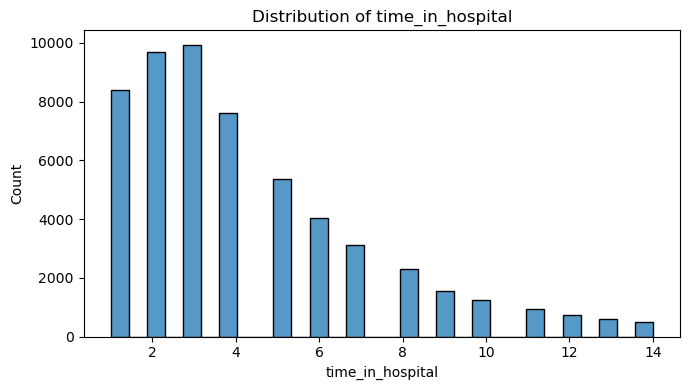

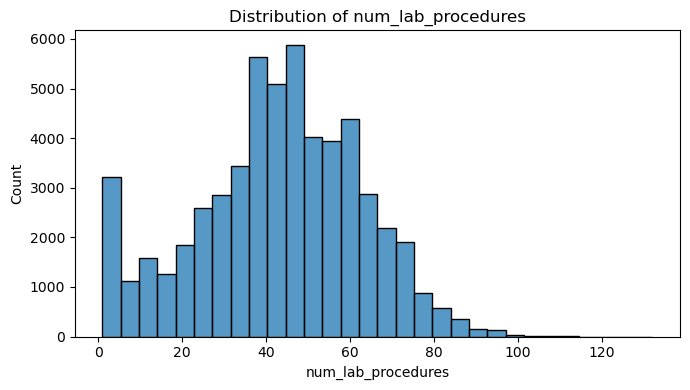

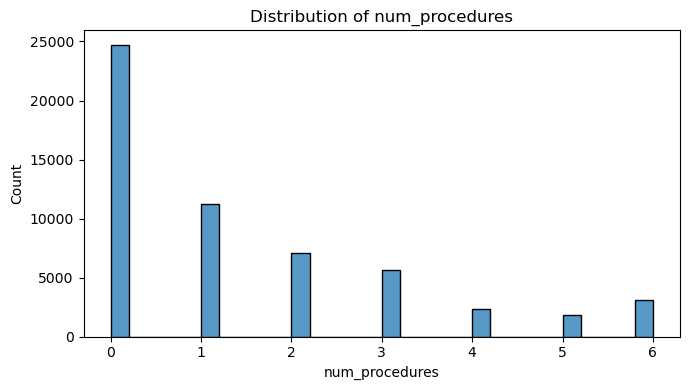

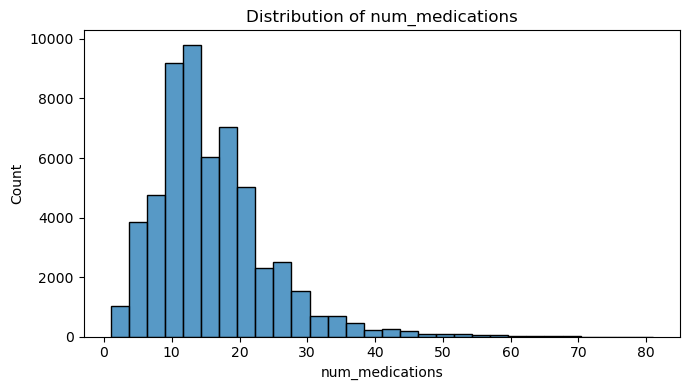

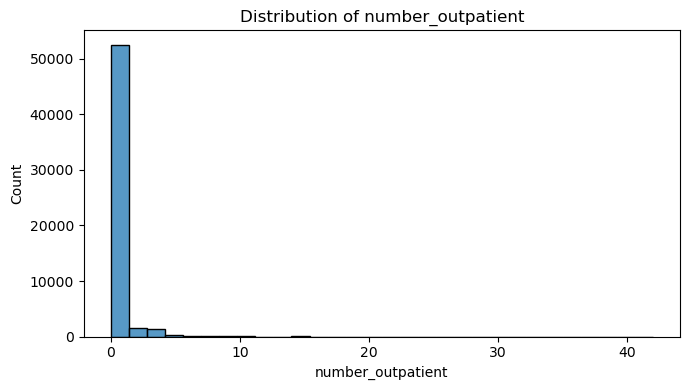

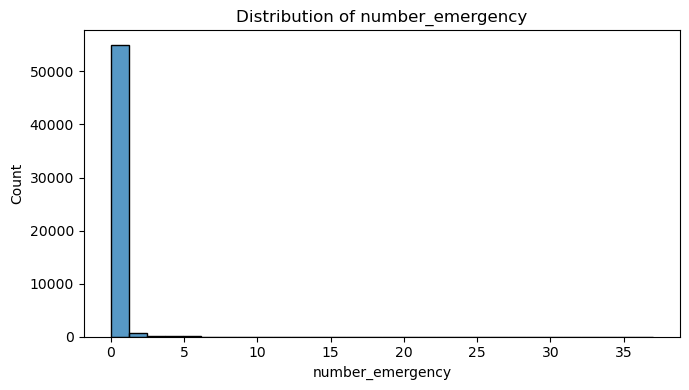

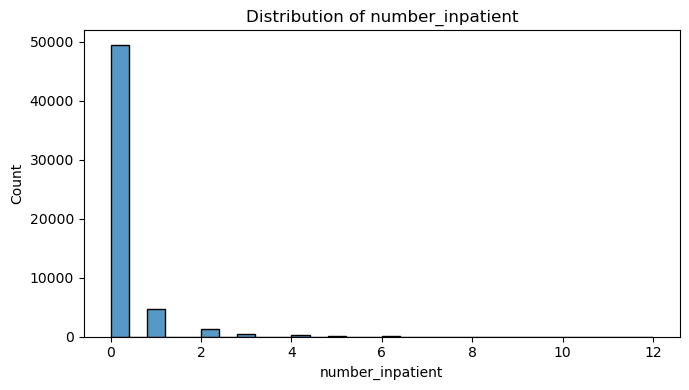

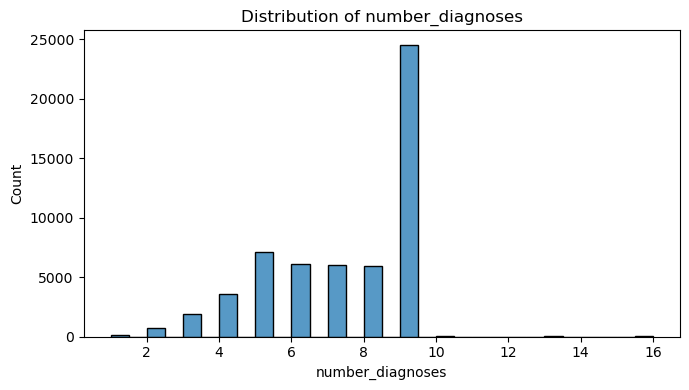

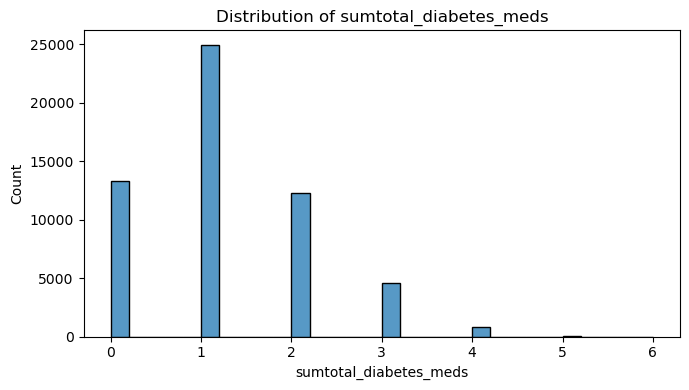

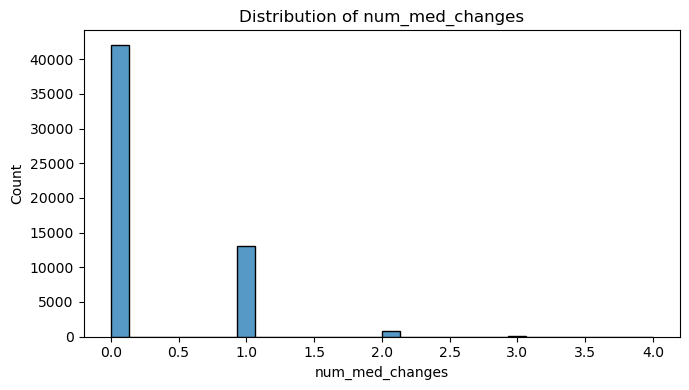

In [25]:
#Overall numeric distributions :
# Numerical variables only - explicitly defining true numerical variables so we can do distribution plot
numeric_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "sumtotal_diabetes_meds",
    "num_med_changes"
]

for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(data=train_df, x=col, bins=30)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

In [26]:
#Quantifying the Skewness of the numerical cols
skewness = (train_df[numeric_cols].skew().sort_values(ascending=False))
print(skewness)

#close to 0 → fairly symmetric
#positive → right-skewed
#negative → left-skewed

number_emergency          16.899238
number_outpatient          9.858446
number_inpatient           5.659423
num_med_changes            1.585275
num_medications            1.434947
num_procedures             1.236455
time_in_hospital           1.173311
sumtotal_diabetes_meds     0.662592
num_lab_procedures        -0.215960
number_diagnoses          -0.720953
dtype: float64


The prior healthcare utilization variables exhibited substantial positive skew, particularly `number_emergency` (16.90), `number_outpatient` (9.86), and `number_inpatient` (5.66). This was primarily attributable to the high proportion of patients with no previous utilization. Among these variables, prior inpatient utilization showed the clearest difference between outcome groups, with 20.11% of patients readmitted within 30 days having at least one previous inpatient admission compared with 10.84% of patients not readmitted within 30 days. Alternative representations of `number_inpatient`, such as a binary indicator or grouped count, were therefore considered

In [27]:
#STEP 3.2. CATEGORICAL COLUMNS

id_cat_cols = ["admission_type_id", "discharge_disposition_id", "admission_source_id"]
#These are actually categorical cols even though they are represented by numbers

other_cat_cols = train_df.select_dtypes(include=["object"]).columns.tolist()

all_cat_cols = id_cat_cols + other_cat_cols

for cat in all_cat_cols:
    readmit_rate = (train_df.groupby(cat, observed=True, dropna=False)["readmitted"].agg(["size", "mean"]).sort_values("mean", ascending=False))                                                        
    readmit_rate["Re-admission rate"] = readmit_rate["mean"] * 100
    print(f"\n--- {cat} ---")
    print(readmit_rate)



--- admission_type_id ---
                    size      mean  Re-admission rate
admission_type_id                                    
6                   3610  0.099169           9.916898
1                  28373  0.091989           9.198886
2                  10235  0.088422           8.842208
5                   2477  0.088413           8.841340
3                  11030  0.082865           8.286491
8                    231  0.069264           6.926407
4                      6  0.000000           0.000000
7                     16  0.000000           0.000000

--- discharge_disposition_id ---
                           size      mean  Re-admission rate
discharge_disposition_id                                    
12                            2  0.500000          50.000000
15                           31  0.451613          45.161290
28                           70  0.300000          30.000000
22                         1127  0.255546          25.554570
5                           738  

In [28]:
#step 3.2.1. Frequency for each value_count within each category

for cat in all_cat_cols:

    freq = (
        train_df[cat]
        .value_counts(dropna=False)
        .to_frame("count")
    )

    freq["percent"] = (
        train_df[cat]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
    )

    print(f"\n--- {cat} ---")
    print(freq.round(2))


--- admission_type_id ---
                   count  percent
admission_type_id                
1                  28373    50.69
3                  11030    19.70
2                  10235    18.28
6                   3610     6.45
5                   2477     4.42
8                    231     0.41
7                     16     0.03
4                      6     0.01

--- discharge_disposition_id ---
                          count  percent
discharge_disposition_id                
1                         35414    63.26
3                          7046    12.59
6                          6623    11.83
18                         1997     3.57
2                          1247     2.23
22                         1127     2.01
5                           738     1.32
25                          614     1.10
4                           437     0.78
7                           325     0.58
23                          206     0.37
28                           70     0.13
8                        

In [29]:
#step 3.2.2. Are there rare categorical columns?
for cat in all_cat_cols:

    pct = (train_df[cat].value_counts(normalize=True, dropna=False).mul(100).sort_values())

    rare = pct[pct < 1]

    if len(rare) > 0:
        print(f"\nRare categories in {cat} (<1%):")
        print(rare.round(2))


Rare categories in admission_type_id (<1%):
admission_type_id
4    0.01
7    0.03
8    0.41
Name: proportion, dtype: float64

Rare categories in discharge_disposition_id (<1%):
discharge_disposition_id
27    0.00
12    0.00
16    0.01
10    0.01
17    0.01
9     0.01
24    0.04
15    0.06
8     0.10
28    0.13
23    0.37
7     0.58
4     0.78
Name: proportion, dtype: float64

Rare categories in admission_source_id (<1%):
admission_source_id
11    0.00
13    0.00
25    0.00
14    0.00
22    0.01
10    0.01
8     0.02
9     0.14
3     0.20
20    0.22
5     0.76
Name: proportion, dtype: float64

Rare categories in race (<1%):
race
Asian    0.71
Name: proportion, dtype: float64

Rare categories in gender (<1%):
gender
Unknown/Invalid    0.0
Name: proportion, dtype: float64

Rare categories in age (<1%):
age
[0-10)     0.22
[10-20)    0.77
Name: proportion, dtype: float64

Rare categories in metformin (<1%):
metformin
Down    0.62
Name: proportion, dtype: float64

Rare categories in repagl

In [30]:
#Step 3.2.3. Medication feature EDA : Readmission rate
for drug in drug_cols:

    if drug not in train_df.columns:
        continue

    print(f"\n--- {drug} ---")

    result = (train_df.groupby(drug, observed=True)["readmitted"].agg(patients="size", readmission_rate="mean"))
    result["readmission_rate"] = result["readmission_rate"]* 100

    print(result)


--- metformin ---
           patients  readmission_rate
metformin                            
Down            346         10.693642
No            44036          9.178854
Steady        10929          8.216671
Up              667          6.746627

--- repaglinide ---
             patients  readmission_rate
repaglinide                            
Down               22          0.000000
No              55237          8.921556
Steady            659         12.291351
Up                 60         21.666667

--- nateglinide ---
             patients  readmission_rate
nateglinide                            
Down                4          0.000000
No              55592          8.972514
Steady            372          9.139785
Up                 10          0.000000

--- chlorpropamide ---
                patients  readmission_rate
chlorpropamide                            
Down                   1          0.000000
No                 55921          8.975161
Steady                53          5

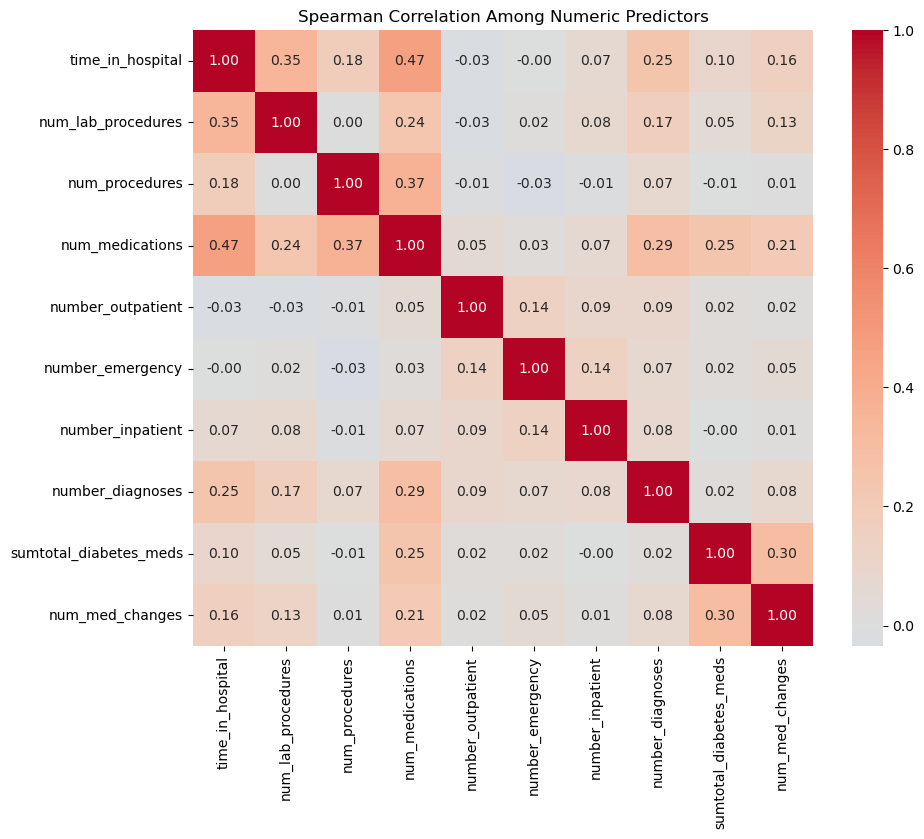

In [31]:
#checking for collinearity for exploratory purposes

numeric_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "sumtotal_diabetes_meds",
    "num_med_changes"
]

corr_matrix = X_train[numeric_cols].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Spearman Correlation Among Numeric Predictors")
plt.show()

In [32]:
#VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

vif_data = X_train[numeric_cols].copy()

# VIF cannot handle missing values
vif_data = vif_data.fillna(vif_data.median())

vif_data = add_constant(vif_data)

vif = pd.DataFrame({
    "feature": vif_data.columns,
    "VIF": [
        variance_inflation_factor(vif_data.values, i)
        for i in range(vif_data.shape[1])
    ]
})

vif = vif[vif["feature"] != "const"].sort_values(
    "VIF",
    ascending=False
)

print(vif)

#VIF	Interpretation
#~1	essentially no multicollinearity
#1–5	usually acceptable
#>5	worth investigating
#>10	potentially serious

                   feature       VIF
4          num_medications  1.668826
1         time_in_hospital  1.392780
3           num_procedures  1.220554
9   sumtotal_diabetes_meds  1.163208
2       num_lab_procedures  1.160106
10         num_med_changes  1.158234
8         number_diagnoses  1.108711
7         number_inpatient  1.033974
6         number_emergency  1.031537
5        number_outpatient  1.018580


In [33]:
#Each cell = number of training rows having that combination
#margins=True adds totals (All)

pd.crosstab(
    X_train["change"],
    X_train["num_med_changes"],
    margins=True
)

#Some notes: when num_med_changes=0, "change" is still capturing 11,365 changes. 
#So my engineered feature is not capturing every type of change (it only measures up and down, not in other ways it's changed)
#With this in mind these two features potentially capture distinct information.

num_med_changes,0,1,2,3,4,All
change,,,,,,
Ch,11365,13100,740,57,2,25264
No,30714,0,0,0,0,30714
All,42079,13100,740,57,2,55978


In [34]:
#num_med_changes>0 always implies that change == Ch, always
#And num_med_changes=0 with "change" still capturing 11365 ch, means change is capturing something num_med_changes cannot
#Are they potentially multicollinear?
X_train_copy=X_train.copy()

change_binary = (X_train_copy["change"] == "Ch").astype(int) #make it binary so we can do spearman correlation

pd.DataFrame({
    "change": change_binary,
    "num_med_changes": X_train_copy["num_med_changes"]
}).corr(method="spearman")



,change,num_med_changes
change,1.000000,0.632285
num_med_changes,0.632285,1.000000


In [35]:
# Exploratory VIF assessment for change and num_med_changes

from statsmodels.tools.tools import add_constant

#Convert the categorical change indicator to binary
check_df = pd.DataFrame({
    "change": X_train["change"].eq("Ch").astype(int),
    "num_med_changes": X_train["num_med_changes"]
})

#Add an intercept before calculating VIF
check_with_constant = add_constant(
    check_df,
    has_constant="add"
)

vif = pd.DataFrame({
    "feature": check_with_constant.columns,
    "VIF": [
        variance_inflation_factor(
            check_with_constant.values,
            feature_index
        )
        for feature_index in range(check_with_constant.shape[1])
    ]
})

#Remove the intercept from the displayed results
vif = (
    vif.loc[vif["feature"].ne("const")]
    .reset_index(drop=True)
)

display(vif.round({"VIF": 2}))

# Interpretation:
# VIF around 1: little linear collinearity
# VIF between 1 and 5: generally acceptable
# VIF above 5: investigate more closely
# VIF above 10: potentially serious


,feature,VIF
0,change,1.59
1,num_med_changes,1.59


NOTES : `change` and `num_med_changes` showed moderate correlation (Spearman ρ = 0.63). 
However, VIF = 1.59, indicating that multicollinearity was not substantial enough to require exclusion of either predictor.
Therefore both were retained.


In [36]:
#Investigating diabetesMed and sumtotal_diabetes_meds:

pd.crosstab(
    X_train["diabetesMed"],
    X_train["sumtotal_diabetes_meds"],
    margins=True
)
#It looks fully deterministic. One needs to be dropped?

sumtotal_diabetes_meds,0,1,2,3,4,5,6,All
diabetesMed,,,,,,,,
No,13311,0,0,0,0,0,0,13311
Yes,0,24948,12300,4581,797,37,4,42667
All,13311,24948,12300,4581,797,37,4,55978


In [37]:
#Does outcome change for increasing number of sumtotal_diabetes_meds
(train_df
    .groupby("sumtotal_diabetes_meds")["readmitted"]
    .agg(
        n="size",
        readmission_rate="mean"
    )
    .assign(
        readmission_rate=lambda x:
        x["readmission_rate"] * 100
    )
)



,n,readmission_rate
sumtotal_diabetes_meds,,
0,13311,7.580197
1,24948,9.591951
2,12300,9.235772
3,4581,9.015499
4,797,8.657465
5,37,0.000000
6,4,50.000000


NOTES: The above two results favours dropping `sumtotal_diabetes_meds` because the readmission rate is similar for having 1-4 meds. And `sumtotal_diabetes_meds`=5 & 6 have small samples sizes.

`diabetesMed` and the engineered `sumtotal_diabetes_meds` feature were deterministically related, with `diabetesMed` = No corresponding exclusively to 
zero diabetes medications and `diabetesMed` = Yes corresponding to one or more medications. Exploratory analysis showed that 30-day readmission differed 
primarily between patients receiving no diabetes medication and those receiving any diabetes medication, while readmission rates were relatively 
similar across patients receiving one to four diabetes medications. Therefore, the binary `diabetesMed` variable was retained and the medication-count 
feature will be excluded to reduce redundancy.

## EDA-informed feature decisions

The transformations below are applied identically to training and test data. Decisions are based only on training-set diagnostics. 

In [38]:
#Final EDA decisions :
#We have previously removed repeating patients
#we have previously dropped "weight" due to extreme missingness, and "examide", "citoglipton", "glimepiride-pioglitazone" due to zero-variance

#1-Drop sumtotal_diabetes_meds
X_train = X_train.drop(columns=["sumtotal_diabetes_meds"])
X_test = X_test.drop(columns=["sumtotal_diabetes_meds"])

#2-Bring in any_number_outpatient to replace number_outpatient (ie make it binary) 
X_train["any_number_outpatient"] = (X_train["number_outpatient"] > 0).astype(int)
X_test["any_number_outpatient"] = (X_test["number_outpatient"] > 0).astype(int)

#2-Collapse number_emergency into 3 categories to collapse sparse tail:
X_train["number_emergency_cat"] = (X_train["number_emergency"].clip(upper=3).astype("category"))
X_test["number_emergency_cat"] = (X_test["number_emergency"].clip(upper=3).astype("category"))

#3-Collapse number_inpatient to 4 categories to collapse sparse tail 
X_train["number_inpatient_cat"] = (X_train["number_inpatient"].clip(upper=4).astype("category"))
X_test["number_inpatient_cat"] = (X_test["number_inpatient"].clip(upper=4).astype("category"))

#4-Drop original columns (number_outpatient, number_inpatient_number_emergency)
X_train = X_train.drop(columns=["number_outpatient", "number_inpatient", "number_emergency"])
X_test = X_test.drop(columns=["number_outpatient", "number_inpatient", "number_emergency"])

#4-Retain unavailable sensitive-group information explicity
X_train["race"] = X_train["race"].fillna("Unknown")
X_test["race"] = X_test["race"].fillna("Unknown")
X_train["gender"] = (X_train["gender"].replace("Unknown/Invalid", "Unknown").fillna("Unknown"))
X_test["gender"] = (X_test["gender"].replace("Unknown/Invalid", "Unknown").fillna("Unknown"))

#5- Medication EDA :
candidate_drug_cols = [col for col in drug_cols
    if col in X_train.columns]

#5.1-Combine sparse dosage-change directions
status_mapping = {
    "Up": "Dose_changed",
    "Down": "Dose_changed"
}

for col in candidate_drug_cols:
    X_train[col] = X_train[col].replace(status_mapping)
    X_test[col] = X_test[col].replace(status_mapping)

#5.2-Measure exposure using training data only
drug_exposure_rates = (
    X_train[candidate_drug_cols]
    .ne("No")
    .mean()
    .sort_values()
)

#5.3- Remove medication features with extremely rare exposure
MIN_DRUG_EXPOSURE_RATE = 0.01

rare_drugs_to_drop = drug_exposure_rates[
    drug_exposure_rates < MIN_DRUG_EXPOSURE_RATE].index.tolist()

X_train = X_train.drop(columns=rare_drugs_to_drop)
X_test = X_test.drop(columns=rare_drugs_to_drop)

print("Medication features removed:")
display(drug_exposure_rates.loc[rare_drugs_to_drop].rename("training_exposure_rate").to_frame())

#6-Verify that train and test have identical features
assert X_train.columns.equals(X_test.columns)
assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)
assert X_train.columns.equals(X_test.columns)
assert X_train.index.equals(y_train.index)
assert X_test.index.equals(y_test.index)


Medication features removed:


,training_exposure_rate
acetohexamide,0.000018
metformin-pioglitazone,0.000018
metformin-rosiglitazone,0.000036
troglitazone,0.000036
glipizide-metformin,0.000089
tolbutamide,0.000232
miglitol,0.000268
tolazamide,0.000411
chlorpropamide,0.001018
acarbose,0.002894


In [39]:
# Final integrity checks before preprocessing

#1-Train and test must contain the same predictors in the same order
assert X_train.columns.equals(X_test.columns), ("Train and test feature columns do not match.")

#2-Feature matrices and targets must have matching row counts
assert len(X_train) == len(y_train), ("X_train and y_train have different numbers of observations.")
assert len(X_test) == len(y_test), ("X_test and y_test have different numbers of observations.")

#3-Feature matrices and targets must retain aligned indexes
assert X_train.index.equals(y_train.index), ("X_train and y_train indexes are not aligned.")
assert X_test.index.equals(y_test.index), ("X_test and y_test indexes are not aligned.")

#4-The target must remain binary and contain no missing values
assert y_train.notna().all(), ("y_train contains missing values.")
assert y_test.notna().all(), ("y_test contains missing values.")
assert set(y_train.unique()).issubset({0, 1}), ("y_train contains values other than 0 and 1.")

assert set(y_test.unique()).issubset({0, 1}), ("y_test contains values other than 0 and 1.")

#5-No duplicate feature names should exist
assert not X_train.columns.duplicated().any(), ("X_train contains duplicated feature names.")
assert not X_test.columns.duplicated().any(), ("X_test contains duplicated feature names.")

#6-Removed predictors must no longer be present
removed_features = {
    "weight",
    "examide",
    "citoglipton",
    "glimepiride-pioglitazone",
    "sumtotal_diabetes_meds",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    *rare_drugs_to_drop,
}

assert removed_features.isdisjoint(X_train.columns), ("At least one removed feature remains in X_train.")
assert removed_features.isdisjoint(X_test.columns), ("At least one removed feature remains in X_test.")

#7-Engineered utilization features must be present
required_engineered_features = {
    "any_number_outpatient",
    "number_emergency_cat",
    "number_inpatient_cat",
    "num_med_changes",
}

assert required_engineered_features.issubset(X_train.columns), ("One or more engineered features are missing from X_train.")
assert required_engineered_features.issubset(X_test.columns), ("One or more engineered features are missing from X_test.")

#8-Known missing sensitive-group labels should have been standardized
assert X_train["race"].notna().all(), ("X_train race still contains missing values.")
assert X_test["race"].notna().all(), ("X_test race still contains missing values.")
assert X_train["gender"].notna().all(), ("X_train gender still contains missing values.")
assert X_test["gender"].notna().all(), ("X_test gender still contains missing values.")
assert "Unknown/Invalid" not in X_train["gender"].unique(), ("Unstandardized gender label remains in X_train.")
assert "Unknown/Invalid" not in X_test["gender"].unique(), ("Unstandardized gender label remains in X_test.")

#9-Up and Down should have been consolidated for retained drug features
retained_drug_cols = [
    col for col in candidate_drug_cols
    if col not in rare_drugs_to_drop
]

for col in retained_drug_cols:
    assert not X_train[col].isin(["Up", "Down"]).any(), (
        f"{col} still contains Up or Down in X_train."
    )
    assert not X_test[col].isin(["Up", "Down"]).any(), (
        f"{col} still contains Up or Down in X_test."
    )

#10-Train and test must remain separate observations
assert set(X_train.index).isdisjoint(set(X_test.index)), ("Training and test sets contain overlapping indexes.")
print("All final pre-processing integrity checks passed.")

All final pre-processing integrity checks passed.


In [40]:
#Checkpoint before model development

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))

print("\nOutcome prevalence - train:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nOutcome prevalence - test:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

print("\nMissing values - train:")
print(
    X_train.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .head(15)
)

print("\nFeature count:", X_train.shape[1])

print(X_train.columns)

Training observations: 55978
Test observations: 13995

Outcome prevalence - train:
readmitted
0    91.03
1     8.97
Name: proportion, dtype: float64

Outcome prevalence - test:
readmitted
0    91.03
1     8.97
Name: proportion, dtype: float64

Missing values - train:
race                        0.0
gender                      0.0
age                         0.0
admission_type_id           0.0
discharge_disposition_id    0.0
admission_source_id         0.0
time_in_hospital            0.0
medical_specialty           0.0
num_lab_procedures          0.0
num_procedures              0.0
num_medications             0.0
number_diagnoses            0.0
max_glu_serum               0.0
A1Cresult                   0.0
metformin                   0.0
dtype: float64

Feature count: 31
Index(['race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'medical_specialty', 'num_lab_procedures', 'num_procedures',
       'num_medicat

In [41]:
#Before moving to preprocessing, first convert the id_cols to category cols just in case
id_cat_cols = ["admission_type_id","discharge_disposition_id", "admission_source_id"]

for col in id_cat_cols:
    X_train[col] = X_train[col].astype("category")
    X_test[col] = X_test[col].astype("category")

In [42]:
#Some final tweaks to explicity define cat cols and num cols before moving to preprocessing:
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumeric columns:")
print(numeric_cols)

print("\nNumber of categorical cols:", len(categorical_cols))
print("Number of numeric cols:", len(numeric_cols))

Categorical columns:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'medical_specialty', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed', 'diag_1_group', 'diag_2_group', 'diag_3_group', 'number_emergency_cat', 'number_inpatient_cat']

Numeric columns:
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses', 'num_med_changes', 'any_number_outpatient']

Number of categorical cols: 24
Number of numeric cols: 7


## STAGE 5 : PREPROCESSING PIPELINE

In [43]:
#STAGE 5 : PREPROCESSING PIPELINE
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

#5.1 - Preprocessing numerical cols: median imputation and standardization
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
     ])

#5.1 - Preprocessing categorical cols: replace missing values with "Unknown", one-hot encode, safely handle categories appearing in test but not train
categorical_transformer= Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

id_catcol_transformer = Pipeline([ #there were some really infrequent (eg n=1) categories in the id cols, best to group it to "infrequent"
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01))
])

model_categorical_cols = [
    col for col in categorical_cols
    if col not in id_cat_cols #remove id cols from the category_cols so it can be processed differently
]

#5.2 - Building the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, model_categorical_cols),
        ("id", id_catcol_transformer, id_cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=True
)



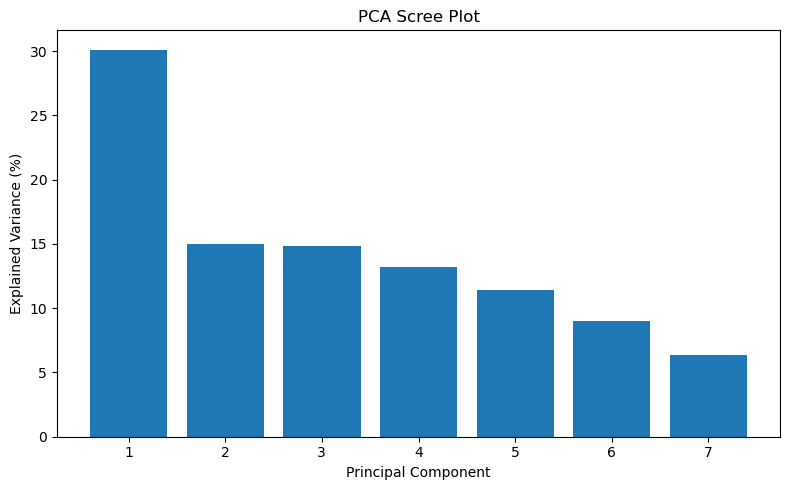

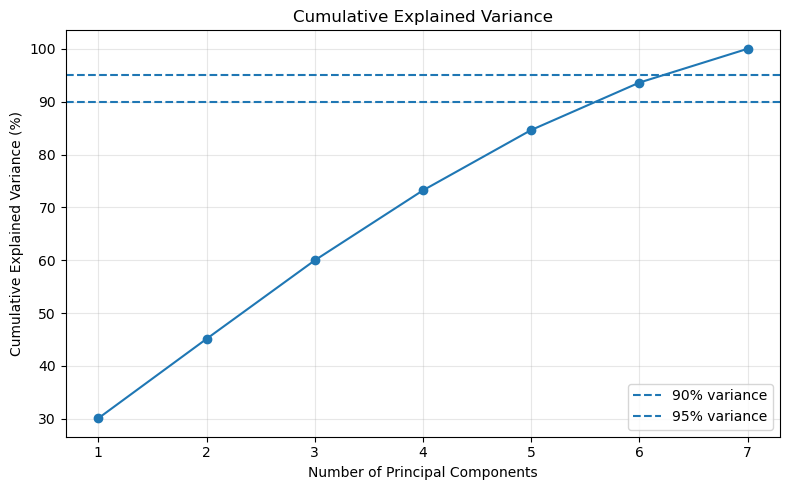

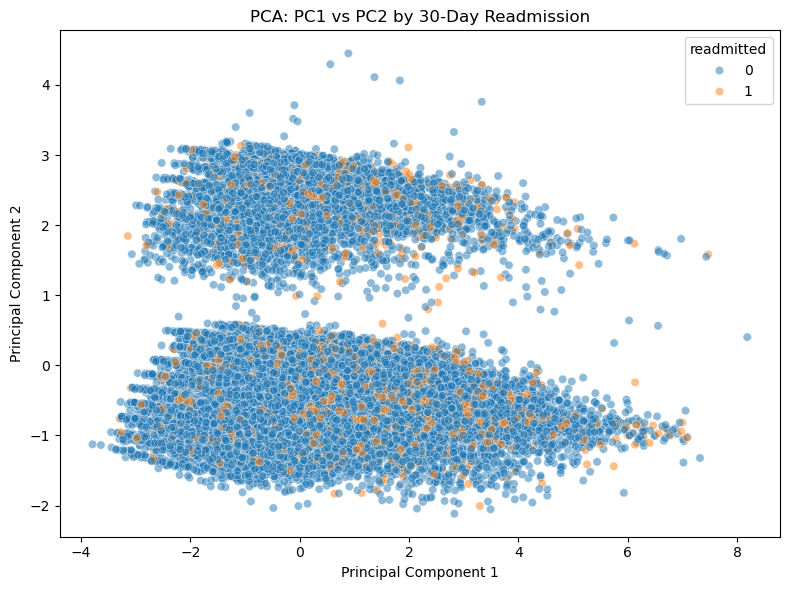

                            PC1       PC2       PC3       PC4       PC5  \
time_in_hospital       0.512022 -0.086555 -0.123225 -0.137183 -0.134806   
num_lab_procedures     0.372863 -0.090435 -0.467585 -0.320966 -0.495606   
num_procedures         0.334460 -0.215489  0.708860  0.169099 -0.068258   
num_medications        0.556353 -0.025924  0.211594  0.130567 -0.026855   
number_diagnoses       0.331926  0.407420 -0.018191 -0.437603  0.695627   
num_med_changes        0.258752  0.055872 -0.440508  0.786061  0.262181   
any_number_outpatient  0.016936  0.876418  0.156671  0.152087 -0.422121   

                            PC6       PC7  
time_in_hospital       0.698877 -0.435587  
num_lab_procedures    -0.534151 -0.014014  
num_procedures        -0.378258 -0.403590  
num_medications        0.133504  0.780663  
number_diagnoses      -0.201562 -0.086503  
num_med_changes       -0.154649 -0.159155  
any_number_outpatient  0.028408 -0.070247  

Loadings for PC1


num_medications          0.556353
time_in_hospital         0.512022
num_lab_procedures       0.372863
num_procedures           0.334460
number_diagnoses         0.331926
num_med_changes          0.258752
any_number_outpatient    0.016936
Name: PC1, dtype: float64

In [44]:
#PCA for dimensionality reduction - in assigment RUBRIC
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA()
X_numeric_scaled = StandardScaler().fit_transform(X_train[numeric_cols])
pca.fit(X_numeric_scaled)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

#1-#Scree plot-variance explained by each PC
plt.figure(figsize=(8, 5))
plt.bar(
    range(1, len(explained_variance) + 1),
    explained_variance * 100
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("PCA Scree Plot")

plt.tight_layout()
plt.show()

#2-Plotting cumulative variance-How many principal components do I need to retain 90% or 95% of the information?
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance * 100,
    marker="o"
)

plt.axhline(y=90, linestyle="--", label="90% variance")
plt.axhline(y=95, linestyle="--", label="95% variance")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Explained Variance")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#3- PCA summary table
pca_summary = pd.DataFrame({
    "Principal Component": range(1, len(explained_variance) + 1),
    "Explained Variance (%)": explained_variance * 100,
    "Cumulative Variance (%)": cumulative_variance * 100
})

pca_summary.round(2)

#4-PCA plot
X_pca = pca.transform(X_numeric_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "readmitted": y_train.values
})

import seaborn as sns
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="readmitted",
    alpha=0.5
)

plt.title("PCA: PC1 vs PC2 by 30-Day Readmission")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

#5-Loadings table
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(numeric_cols))],
    index=numeric_cols
)

print(loadings)

#sort loadings for PC1
print("\nLoadings for PC1")
loadings["PC1"].sort_values(key=abs, ascending=False)

PCA was explored as a dimensionality-reduction technique. However, because the dataset contained many clinically meaningful categorical predictors 
and interpretability was important, PCA was used as an exploratory/comparison analysis rather than replacing the original features in the final model.


## STAGE 6. MODEL IMPLEMENTATION

In [47]:
#STAGE 6.1 : DUMMY CLASSIFIER BASELINE: "How well can we perform if we completely ignore the predictors and only know the prevalence of 30-day readmission?

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

#Use the same stratified CV folds for all models
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#Use the same evaluation metrics as the real models
scoring = {
    "Average_Precision": "average_precision",
    "ROC_AUC": "roc_auc",
    "Recall": "recall",
    "Precision": "precision",
    "F1": "f1",
    "Balanced_accuracy": "balanced_accuracy",
    "Brier": "neg_brier_score"
}

#DummyClassifier(strategy="prior") learns only the class distribution
#It does NOT learn relationships between the predictors and readmission
dummy_model = DummyClassifier(
    strategy="prior",
    random_state=42
)

#5-fold cross-validation on the TRAINING SET ONLY
dummy_results = cross_validate(
    dummy_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

#Average CV results
dummy_summary = pd.Series({
    metric: dummy_results[f"test_{metric}"].mean()
    for metric in scoring
})

#sklearn returns negative Brier score, convert back to positive
dummy_summary["Brier"] = -dummy_summary["Brier"]

print("Dummy Classifier CV Performance")
display(dummy_summary.round(3))

Dummy Classifier CV Performance


PR_AUC               0.090
ROC_AUC              0.500
Recall               0.000
Precision            0.000
F1                   0.000
Balanced_accuracy    0.500
Brier                0.082
dtype: float64

In [48]:
#STAGE 6.2 : BASELINE LOG REGRESSION - with non-balanced weight

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

baseline_logreg = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=3000, class_weight=None, random_state=42))
])


baseline_results = cross_validate(baseline_logreg, X_train, y_train, cv=cv, scoring = scoring, n_jobs=-1)

baseline_summary = pd.Series({metric: baseline_results[f"test_{metric}"].mean()
                              for metric in scoring})

baseline_summary["Brier"] = -1*baseline_summary["Brier"]  #sklearn returns neg brier score so we need to make it positive


print("BASELINE Log regression with non-balanced weight")
display(baseline_summary.round(3))



BASELINE Log regression with non-balanced weight


PR_AUC               0.161
ROC_AUC              0.644
Recall               0.001
Precision            0.207
F1                   0.002
Balanced_accuracy    0.500
Brier                0.080
dtype: float64

In [49]:
#STAGE 6.3 : Preliminary LOG REG model - a) class_weight=balanced vs none 

#6.3.1. Start with Normal Log regression 
logreg_normal = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=3000, random_state=42, class_weight=None))
])

#6.3.2. Then do Balanced Log Regression
logreg_balanced = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=3000, random_state=42, class_weight="balanced"))
])

#6.3.3. Run cross-validation on both using the same CV folds
logresults_normal= cross_validate( #cross_validate : trains and evaluates your model repeatedly using those folds.
    logreg_normal, 
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1)

logresults_balanced = cross_validate(
    logreg_balanced,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1)

#6.3.4. Plot to compare
results = pd.DataFrame({
    "Normal": {
        metric: logresults_normal[f"test_{metric}"].mean()
        for metric in scoring},
    "Balanced": {
        metric: logresults_balanced[f"test_{metric}"].mean()
        for metric in scoring}
})


results.loc["Brier"] *= -1 
display(results.round(3))


,Normal,Balanced
PR_AUC,0.161,0.160
ROC_AUC,0.644,0.645
Recall,0.001,0.534
Precision,0.207,0.138
F1,0.002,0.219
Balanced_accuracy,0.500,0.602
Brier,0.080,0.230


NOTES : Class weighting changed the classification behavior at the default 0.5 threshold but produced little improvement in ranking performance (Average-Precision/ROC-AUC). The balanced model substantially increased recall but reduced precision and probability calibration, as reflected by its higher Brier score. Consequently, class weighting and classification threshold were treated as separate tuning decisions.

In [51]:
#6.3.4 Baseline Log regression : CHECK FEATURE SELECTION VS NONE (We use the default class_weight=None for the moment)

from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (recall_score, precision_score, f1_score, balanced_accuracy_score, confusion_matrix)
from sklearn.model_selection import cross_val_predict

l1_selector = SelectFromModel(LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.1,
    max_iter=3000,
    class_weight=None, #unbalanced
    random_state=42)
)
#1-Log Reg with L1 feature selection
logreg_fs = Pipeline([
    ("preprocessing", preprocessor),
    ("feature_selection", l1_selector),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight=None,
        random_state=42))
])

#2-Log Reg without feature selection
logreg_no_fs = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight=None,
        random_state=42))
])

#4-Get out-of-fold probabilities for both
oof_no_fs = cross_val_predict(
    logreg_no_fs,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

oof_fs = cross_val_predict(
    logreg_fs,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

#5-Convert probabilities into classification using default threshold of 0.5 for the moment
pred_no_fs = (oof_no_fs >= 0.5).astype(int)
pred_fs = (oof_fs >= 0.5).astype(int)

#6-Compare both models
from sklearn.metrics import (
    roc_auc_score, average_precision_score, recall_score,
    precision_score, f1_score, balanced_accuracy_score,
    brier_score_loss
)

def evaluate_model(y_true, y_prob, y_pred):
    return {
        "Average_Precision": average_precision_score(y_true, y_prob),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "Recall": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Specificity": recall_score(y_true, y_pred, pos_label=0), #you tell sklearn to treat 0 as the class of interest. It then calculates:tn/(tn+fp)
        "F1": f1_score(y_true, y_pred),
        "Balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "Brier": brier_score_loss(y_true, y_prob)
    }

comparison_fs = pd.DataFrame({
    "No feature selection": evaluate_model(y_train, oof_no_fs, pred_no_fs),
    "L1 feature selection": evaluate_model(y_train, oof_fs, pred_fs)
})

display(comparison_fs.round(3))

,No feature selection,L1 feature selection
PR_AUC,0.160,0.160
ROC_AUC,0.644,0.644
Recall,0.001,0.001
Precision,0.222,0.389
Specificity,1.000,1.000
F1,0.002,0.003
Balanced_accuracy,0.500,0.501
Brier,0.080,0.080


In [52]:
#STAGE 8 : HYPERPARAM TUNING - LET CV TEST L1 VS NOT, BALANCED VS UNBALANCED
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFromModel

#8.1. Create a general pipeline
tuning_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("feature_selection", "passthrough"),  #Default = no selection
    ("model", LogisticRegression(solver="liblinear", max_iter=3000, random_state=42))
])

#8.2. # Define two parameter grids:
# 1. Logistic Regression without a separate feature-selection step
# 2. Logistic Regression with L1-based SelectFromModel

param_grid = [{"feature_selection": ["passthrough"], #without L1 feature selection
               "model__C": [0.01, 0.1, 1, 10],
               "model__penalty": ["l1", "l2"],
               "model__class_weight": [None, "balanced"]},
              
              {"feature_selection": [SelectFromModel(LogisticRegression( #With feature selection
                  penalty="l1",
                  solver="liblinear",
                  max_iter=3000,
                  random_state=42))],
               "feature_selection__estimator__C": [0.01, 0.05, 0.1, 0.5, 1], #strength of feature selection
               "model__C": [0.01, 0.1, 1, 10], #controls regularization of final model
               "model__penalty": ["l1", "l2"],
               "model__class_weight": [None, "balanced"]}
             ]

#8.3. GridSearchCV
tuning_scoring = {
    "Average_Precision": "average_precision",
    "ROC_AUC": "roc_auc",
    "Recall": "recall",
    "Precision": "precision",
    "F1": "f1",
    "Balanced_Accuracy": "balanced_accuracy",
    "Brier": "neg_brier_score"
}

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring=tuning_scoring,
    refit="Average_Precision",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    return_train_score=True,
    error_score="raise" #helpful during development because invalid configurations will fail visibly instead of quietly receiving NaN.
)

grid_search.fit(X_train, y_train)

best_lr = grid_search.best_estimator_

print("Best Average_Precision:", grid_search.best_score_)
print("Best parameters:")
print(grid_search.best_params_)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best Average_Precision: 0.16158050861009746
Best parameters:
{'feature_selection': SelectFromModel(estimator=LogisticRegression(max_iter=3000, penalty='l1',
                                             random_state=42,
                                             solver='liblinear')), 'feature_selection__estimator__C': 0.1, 'model__C': 1, 'model__class_weight': None, 'model__penalty': 'l1'}


Because the positive readmission class represented approximately 9% of observations, primary model metric to be used: Average Precision (AP), selected because the positive class is uncommon. AP summarises performance across the precision–recall curve and is referred to consistently as Average Precision throughout this analysis

`SelectFromModel` does not necessarily select every nonzero coefficient. Its default threshold is based on coefficient magnitude. Therefore this is magnitude-based selection of coefficients. 

In [53]:
#save winning model
best_lr = grid_search.best_estimator_

all_features = (best_lr.named_steps["preprocessing"].get_feature_names_out())

selector = best_lr.named_steps["feature_selection"] #How many features did L1 selector retain?

selected_mask = selector.get_support()

selected_features = all_features[selected_mask]

print("Features before selection:", len(all_features))
print("Features retained:", len(selected_features))
print("Features removed:", len(all_features) - len(selected_features))

Features before selection: 129
Features retained: 72
Features removed: 57


In [54]:
#Coefficient table after fitting best_lr
selected_features = all_features[selected_mask]

coefficients = (
    pd.DataFrame({
        "feature": selected_features,
        "coefficient": best_lr
            .named_steps["model"]
            .coef_[0]
    })
    .assign(
        odds_ratio=lambda frame:
        np.exp(frame["coefficient"])
    )
    .sort_values(
        "coefficient",
        key=abs,
        ascending=False
    )
)

display(coefficients.head(20))

,feature,coefficient,odds_ratio
54,cat__number_inpatient_cat_0,-1.101646,0.332324
67,id__discharge_disposition_id_25,-0.901308,0.406038
66,id__discharge_disposition_id_22,0.895098,2.447575
55,cat__number_inpatient_cat_1,-0.647715,0.523240
61,id__discharge_disposition_id_1,-0.622524,0.536588
63,id__discharge_disposition_id_5,0.615141,1.849917
41,cat__diag_2_group_Neoplasms,0.449955,1.568242
64,id__discharge_disposition_id_6,-0.374375,0.687719
56,cat__number_inpatient_cat_2,-0.374143,0.687879
53,cat__number_emergency_cat_3,0.298664,1.348056


In [55]:
# Inspect hyperparameter-tuning results
cv_results = pd.DataFrame(grid_search.cv_results_)
tuning_results = cv_results.copy()

# Convert sklearn's negative Brier score to positive Brier loss
tuning_results["mean_test_Brier"] = (
    -tuning_results["mean_test_Brier"]
)

tuning_results[
    [
        "rank_test_Average_Precision",
        "mean_test_Average_Precision",
        "mean_test_ROC_AUC",
        "mean_test_Recall",
        "mean_test_Precision",
        "mean_test_F1",
        "mean_test_Balanced_Accuracy",
        "mean_test_Brier",
        "params"
    ]
].sort_values(
    "rank_test_Average_Precision"
).head(10)

,rank_test_Average_Precision,mean_test_Average_Precision,mean_test_ROC_AUC,mean_test_Recall,mean_test_Precision,mean_test_F1,mean_test_Balanced_Accuracy,mean_test_Brier,params
56,1,0.161581,0.644507,0.000796,0.356667,0.001588,0.500290,0.079508,{'feature_selection': SelectFromModel(estimato...
60,2,0.161535,0.644119,0.001195,0.310000,0.002379,0.500480,0.079521,{'feature_selection': SelectFromModel(estimato...
61,3,0.161485,0.644071,0.001195,0.310000,0.002379,0.500480,0.079525,{'feature_selection': SelectFromModel(estimato...
57,4,0.161484,0.644175,0.000796,0.256667,0.001587,0.500280,0.079521,{'feature_selection': SelectFromModel(estimato...
88,5,0.161279,0.644389,0.000796,0.256667,0.001587,0.500280,0.079522,{'feature_selection': SelectFromModel(estimato...
8,6,0.161270,0.644408,0.000796,0.256667,0.001587,0.500280,0.079522,"{'feature_selection': 'passthrough', 'model__C..."
72,7,0.161265,0.644386,0.000796,0.256667,0.001587,0.500280,0.079523,{'feature_selection': SelectFromModel(estimato...
4,8,0.161202,0.646364,0.000597,0.500000,0.001193,0.500269,0.079478,"{'feature_selection': 'passthrough', 'model__C..."
52,9,0.161193,0.646420,0.000597,0.500000,0.001193,0.500269,0.079480,{'feature_selection': SelectFromModel(estimato...
84,10,0.161139,0.646456,0.000597,0.500000,0.001193,0.500269,0.079479,{'feature_selection': SelectFromModel(estimato...


In [56]:
#STAGE 8: Obtain out-of-fold probabilities from the tuned model

tuned_lr_oof_prob = cross_val_predict(best_lr, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
tuned_lr_oof_prob 

array([0.07180745, 0.1001734 , 0.0763703 , ..., 0.06887612, 0.05813688,
       0.12381887])

In [57]:
#STAGE: Threshold optimization. Can also obtain the exact Youden-optimal threshold from the ROC curve:
# Select the exact OOF threshold that maximises Youden's J

from sklearn.metrics import roc_curve

fpr, tpr, roc_thresholds = roc_curve(y_train, tuned_lr_oof_prob)

youden_j = tpr - fpr
best_index = np.argmax(youden_j)

best_threshold = roc_thresholds[best_index]
best_recall = tpr[best_index]
best_specificity = 1 - fpr[best_index]
best_youden_j = youden_j[best_index]

print(f"Selected threshold: {best_threshold:.4f}")
print(f"OOF recall: {best_recall:.3f}")
print(f"OOF specificity: {best_specificity:.3f}")
print(f"Youden's J: {best_youden_j:.3f}")

Selected threshold: 0.0836
OOF recall: 0.588
OOF specificity: 0.622
Youden's J: 0.211


NOTE: Youden’s J was selected as a neutral threshold criterion that gives equal weight to sensitivity and specificity. In deployment, the threshold should be reconsidered using intervention capacity and the relative costs of false negatives and false positives.

In [58]:
#Apply the selected threshold to OOF probabilities
tuned_lr_oof_pred = (tuned_lr_oof_prob >= best_threshold).astype(int)

tuned_lr_cv_results = evaluate_model(y_train, tuned_lr_oof_prob, tuned_lr_oof_pred)

pd.Series(tuned_lr_cv_results).round(3)

PR_AUC               0.160
ROC_AUC              0.645
Recall               0.588
Precision            0.133
Specificity          0.622
F1                   0.217
Balanced_accuracy    0.605
Brier                0.080
dtype: float64

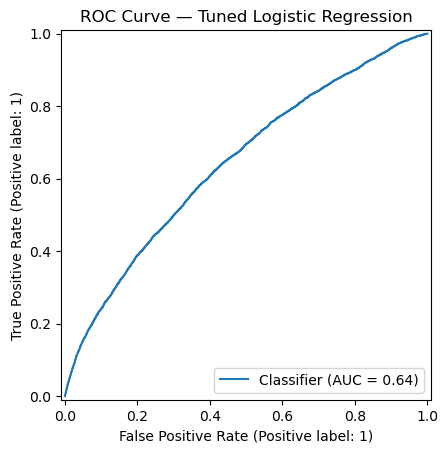

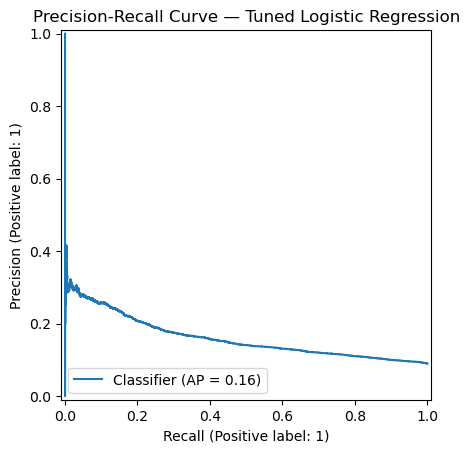

In [59]:
#ROC and Precision-Recall curves
from sklearn.metrics import (RocCurveDisplay, PrecisionRecallDisplay)

RocCurveDisplay.from_predictions(y_train, tuned_lr_oof_prob)
plt.title("ROC Curve — Tuned Logistic Regression")
plt.show()

PrecisionRecallDisplay.from_predictions(y_train, tuned_lr_oof_prob)
plt.title("Precision-Recall Curve — Tuned Logistic Regression")

plt.show()

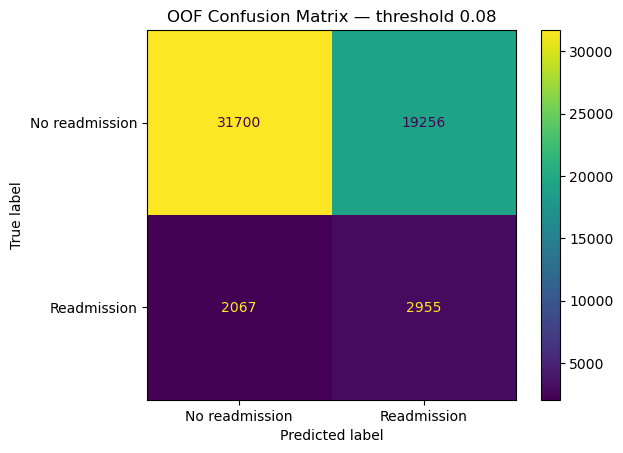

In [60]:
#CONFUSION MATRIX
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_train, tuned_lr_oof_pred, display_labels=["No readmission", "Readmission"])
plt.title(f"OOF Confusion Matrix — threshold {best_threshold:.2f}")
plt.show()

In [77]:
#STAGE 10 - Random Forest as a second model

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1))
])


rf_param_grid = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 5, 10],
    "model__max_features": ["sqrt", "log2"],
    "model__class_weight": [None, "balanced"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=20,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

#fit
rf_search.fit(X_train, y_train)

print("Best Random Forest PR-AUC:", rf_search.best_score_)
print("\nBest Random Forest parameters:")
print(rf_search.best_params_)

#save it 
best_rf = rf_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Random Forest PR-AUC: 0.1742002488982144

Best Random Forest parameters:
{'model__n_estimators': 400, 'model__min_samples_split': 5, 'model__min_samples_leaf': 5, 'model__max_features': 'log2', 'model__max_depth': 20, 'model__class_weight': None}


In [78]:
#Generate RF OOF predictions

rf_oof_prob = cross_val_predict(best_rf, X_train, y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]



In [80]:
#RF BEST Threshold
def find_best_threshold(y_true, y_prob):

    results = []

    for threshold in np.arange(0.01, 1.00, 0.01):
        y_pred = (y_prob >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        specificity = tn / (tn + fp)
        sensitivity = recall_score(y_true, y_pred)

        results.append({
            "threshold": threshold,
            "recall": sensitivity,
            "specificity": specificity,
            "precision": precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "f1": f1_score(
                y_true,
                y_pred
            ),
            "balanced_accuracy":
                balanced_accuracy_score(
                    y_true,
                    y_pred
                ),
            "youden_j":
                sensitivity
                + specificity
                - 1
        })

    results_df = pd.DataFrame(results)

    best_row = results_df.loc[results_df["youden_j"].idxmax()]

    return (best_row["threshold"], results_df)

#Use this function to find best hreshold
rf_threshold, rf_threshold_df = (find_best_threshold(y_train, rf_oof_prob))
print("RF threshold:", round(rf_threshold, 2))

RF threshold: 0.1


In [81]:
#Predict using this threshold
rf_oof_pred = (rf_oof_prob >= rf_threshold).astype(int)

#Evaluation:
rf_cv_results = evaluate_model(y_train, rf_oof_prob, rf_oof_pred)
pd.Series(rf_cv_results).round(3)

ROC_AUC              0.652
PR_AUC               0.173
Recall               0.515
Precision            0.145
Specificity          0.700
F1                   0.226
Balanced_accuracy    0.608
Brier                0.079
dtype: float64

In [82]:
#STAGE 10 - COMPARE LOG REGRESSION VS RANDOM FOREST

model_comparison = pd.DataFrame({
    "Tuned Logistic Regression": tuned_lr_cv_results,
    "Tuned Random Forest": rf_cv_results})

model_comparison.round(3)

,Tuned Logistic Regression,Tuned Random Forest
ROC_AUC,0.644,0.652
PR_AUC,0.160,0.173
Recall,0.621,0.515
Precision,0.129,0.145
Specificity,0.586,0.700
F1,0.213,0.226
Balanced_accuracy,0.604,0.608
Brier,0.080,0.079


In [83]:
#STAGE 10 : XGBOOST
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        tree_method="hist"))
])

xgb_params = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.9, 1.0]}

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=20,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_

print(xgb_search.best_params_)
print(xgb_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'model__subsample': 0.7, 'model__n_estimators': 600, 'model__max_depth': 7, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}
0.18108647942936235


In [86]:
#XGBOOST OOF PROBABILITIES
xgb_oof_prob = cross_val_predict(
    best_xgb,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

xgb_threshold, xgb_threshold_df = (find_best_threshold(y_train, xgb_oof_prob))

xgb_oof_pred = (xgb_oof_prob >= xgb_threshold).astype(int)

#Evaluation
xgb_cv_results = evaluate_model(
    y_train,
    xgb_oof_prob,
    xgb_oof_pred)

pd.Series(xgb_cv_results).round(3)

ROC_AUC              0.654
PR_AUC               0.180
Recall               0.654
Precision            0.129
Specificity          0.565
F1                   0.216
Balanced_accuracy    0.609
Brier                0.079
dtype: float64

In [105]:
#DUMMY CLASSIFIER OOF PREDICTIONS FOR FINAL MODEL COMPARISON-part1
#LR/RF/XGBoost results are produced using evaluate_model() function after OOF predictions and threshold selection, 
#whereas dummy_summary comes directly from cross_validate.

from sklearn.model_selection import cross_val_predict

dummy_oof_prob = cross_val_predict(
    dummy_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

#Dummy prior probability is below 0.5 because readmission is the minority class
dummy_oof_pred = (dummy_oof_prob >= 0.5).astype(int)

dummy_cv_results = evaluate_model(
    y_train,
    dummy_oof_prob,
    dummy_oof_pred
)

pd.Series(dummy_cv_results).round(3)

ROC_AUC              0.500
PR_AUC               0.090
Recall               0.000
Precision            0.000
Specificity          1.000
F1                   0.000
Balanced_accuracy    0.500
Brier                0.082
dtype: float64

In [107]:
#ALL MODEL COMPARISON : training-set OOF validation performance.-part2
model_comparison = pd.DataFrame({
    "Dummy Classifier": dummy_cv_results,
    "Logistic Regression":
        tuned_lr_cv_results,
    "Random Forest":
        rf_cv_results,
    "XGBoost":
        xgb_cv_results
})

model_comparison.round(3)

,Dummy Classifier,Logistic Regression,Random Forest,XGBoost
ROC_AUC,0.500,0.644,0.652,0.654
PR_AUC,0.090,0.160,0.173,0.180
Recall,0.000,0.621,0.515,0.654
Precision,0.000,0.129,0.145,0.129
Specificity,1.000,0.586,0.700,0.565
F1,0.000,0.213,0.226,0.216
Balanced_accuracy,0.500,0.604,0.608,0.609
Brier,0.082,0.080,0.079,0.079


In [90]:
#XGBOOST IS THE CHOSEN MODEL FOR THIS DATASET

#1-Best XGBoost pipeline selected using CV average precision / PR-AUC
final_xgb = xgb_search.best_estimator_

print("Best CV PR-AUC:", xgb_search.best_score_)
print("Best parameters:")
print(xgb_search.best_params_)

Best CV PR-AUC: 0.18108647942936235
Best parameters:
{'model__subsample': 0.7, 'model__n_estimators': 600, 'model__max_depth': 7, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}


In [93]:
final_threshold = xgb_threshold
print("Final OOF-selected threshold: ", final_threshold)

Final OOF-selected threshold:  0.08


In [94]:
#2-Refit final XGB pipeline on entire training set
final_xgb.fit(X_train, y_train)

#3-Generate probabilities on the untouched test set
test_proba = final_xgb.predict_proba(X_test)[:, 1] #we want our oof-selected threshold so dont .predict(X_test)

#4-Apply OOF-threshold
test_pred = (test_proba >= final_threshold).astype(int)

#5-Calculate all final metrics
#Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()
specificity = tn / (tn + fp)

#Final test metrics
test_metrics = pd.Series({
    "ROC_AUC": roc_auc_score(y_test, test_proba),
    "PR_AUC": average_precision_score(y_test, test_proba),
    "Recall": recall_score(y_test, test_pred),
    "Precision": precision_score(y_test, test_pred, zero_division=0),
    "Specificity": specificity,
    "F1": f1_score(y_test, test_pred),
    "Balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
    "Brier": brier_score_loss(y_test, test_proba)
})

print("Final XGBoost test performance")
print(test_metrics.round(3))

Final XGBoost test performance
ROC_AUC              0.652
PR_AUC               0.182
Recall               0.648
Precision            0.128
Specificity          0.567
F1                   0.214
Balanced_accuracy    0.607
Brier                0.079
dtype: float64


In [95]:
#Final Confusion Matrix
cm = confusion_matrix(y_test, test_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Negative", "Actual Positive"],
    columns=["Predicted Negative", "Predicted Positive"]
)

print(cm_df)

                 Predicted Negative  Predicted Positive
Actual Negative                7225                5515
Actual Positive                 442                 813


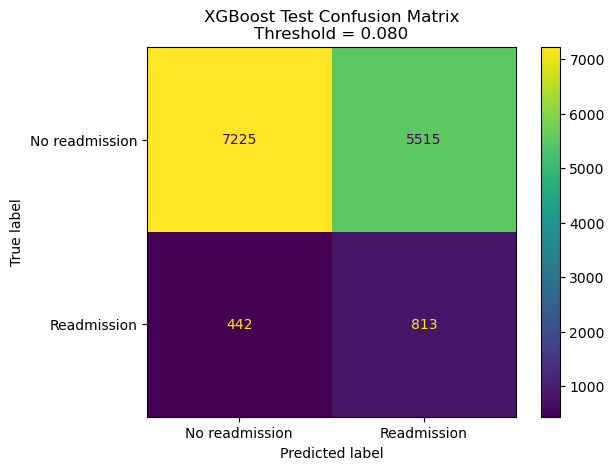

In [96]:
#Lets visualize final confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No readmission", "Readmission"]
).plot()

plt.title(f"XGBoost Test Confusion Matrix\nThreshold = {final_threshold:.3f}")
plt.show()

In [97]:
#Compare final test PR-AUC vs no-skill baseline
test_prevalence = y_test.mean()

print(f"Positive class prevalence: {test_prevalence:.3f}")
print(f"Final XGBoost PR-AUC: {test_metrics['PR_AUC']:.3f}")
print(f"PR-AUC lift over prevalence: "
      f"{test_metrics['PR_AUC'] / test_prevalence:.2f}x")

Positive class prevalence: 0.090
Final XGBoost PR-AUC: 0.182
PR-AUC lift over prevalence: 2.03x


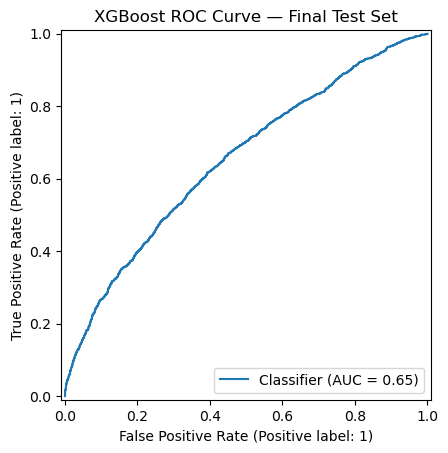

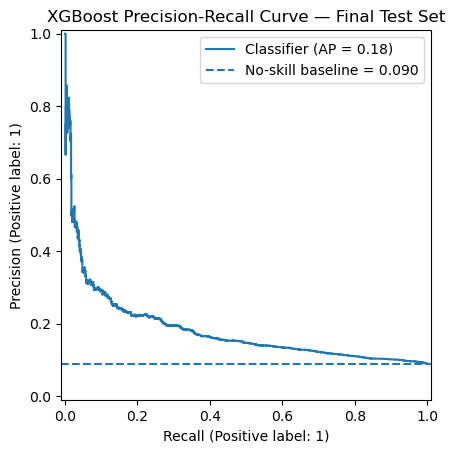

In [98]:
#Plot ROC curve and PR-Curve

RocCurveDisplay.from_predictions(y_test, test_proba)
plt.title("XGBoost ROC Curve — Final Test Set")
plt.show()


PrecisionRecallDisplay.from_predictions(y_test, test_proba)

plt.axhline(
    y=test_prevalence,
    linestyle="--",
    label=f"No-skill baseline = {test_prevalence:.3f}"
)

plt.title("XGBoost Precision-Recall Curve — Final Test Set")
plt.legend()
plt.show()


In [99]:
#Compare OOF performance vs final test performance
xgb_oof_metrics = pd.Series({
    "ROC_AUC": 0.654,
    "PR_AUC": 0.180,
    "Recall": 0.654,
    "Precision": 0.129,
    "Specificity": 0.565,
    "F1": 0.216,
    "Balanced_accuracy": 0.609,
    "Brier": 0.079
})

#compare
comparison = pd.DataFrame({
    "OOF_CV": xgb_oof_metrics,
    "Final_Test": test_metrics})

comparison["Difference_Test_minus_OOF"] = (comparison["Final_Test"] - comparison["OOF_CV"])

print(comparison.round(3))

                   OOF_CV  Final_Test  Difference_Test_minus_OOF
ROC_AUC             0.654       0.652                     -0.002
PR_AUC              0.180       0.182                      0.002
Recall              0.654       0.648                     -0.006
Precision           0.129       0.128                     -0.001
Specificity         0.565       0.567                      0.002
F1                  0.216       0.214                     -0.002
Balanced_accuracy   0.609       0.607                     -0.002
Brier               0.079       0.079                     -0.000


## STAGE 12: MODEL EXPLAINABILITY

The final XGBoost model is interpreted using SHAP (SHapley Additive exPlanations).

SHAP is used for two purposes:

1. **Global explainability** – identifying which features contribute most strongly to model predictions across patients.
2. **Local explainability** – explaining why the model assigned a particular risk score to an individual patient.

Because the final model is a preprocessing + XGBoost pipeline, the test data must first be transformed using the preprocessing component fitted on the training data. SHAP explanations are then generated using the fitted XGBoost model.

A Partial Dependence Plot (PDP) is also used to examine how an important numerical feature is associated with predicted readmission risk while averaging over the other features.

In [109]:
#!pip install shap


   ---------------------------------------- 0/2 [slicer]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ----

In [110]:
#STAGE 12.1 - IMPORT EXPLAINABILITY LIBRARIES
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [111]:
#STAGE 12.2 - EXTRACT FITTED PREPROCESSOR AND XGBOOST MODEL
#The final pipeline (final_xgb) is an object and has already been fitted: final_xgb.fit(X_train, y_train)

final_preprocessor = final_xgb.named_steps["preprocessing"]
final_xgb_model = final_xgb.named_steps["model"]

#Get names of features AFTER preprocessing
feature_names = final_preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))
print("\nFirst 20 transformed feature names:")
print(feature_names[:20])

Number of transformed features: 136

First 20 transformed feature names:
['num__time_in_hospital' 'num__num_lab_procedures' 'num__num_procedures'
 'num__num_medications' 'num__number_diagnoses' 'num__num_med_changes'
 'num__any_number_outpatient' 'cat__race_AfricanAmerican'
 'cat__race_Asian' 'cat__race_Caucasian' 'cat__race_Hispanic'
 'cat__race_Other' 'cat__race_Unknown' 'cat__gender_Female'
 'cat__gender_Male' 'cat__gender_Unknown' 'cat__age_[0-10)'
 'cat__age_[10-20)' 'cat__age_[20-30)' 'cat__age_[30-40)']


In [112]:
#STAGE 12.3 - PREPARE TEST SAMPLE FOR SHAP

#Use a reproducible sample from the untouched test set
rng = np.random.RandomState(42)

shap_sample_size = min(1000, len(X_test))

shap_positions = rng.choice(
    len(X_test),
    size=shap_sample_size,
    replace=False
)

#Original, unprocessed observations
X_shap_original = X_test.iloc[shap_positions].copy()

#Apply only the preprocessing fitted inside final_xgb
X_shap_transformed = final_preprocessor.transform(X_shap_original)

#SHAP plotting is easier with a dense matrix.
#We will convert only this 1,000-row sample, not the entire dataset.
if sparse.issparse(X_shap_transformed):
    X_shap_transformed = X_shap_transformed.toarray()

#Create dataframe so SHAP plots show meaningful feature names
X_shap_df = pd.DataFrame(
    X_shap_transformed,
    columns=feature_names,
    index=X_shap_original.index
)

print("SHAP sample shape:", X_shap_df.shape)

X_shap_df.head()

SHAP sample shape: (1000, 136)


,num__time_in_hospital,num__num_lab_procedures,num__num_procedures,num__num_medications,num__number_diagnoses,num__num_med_changes,num__any_number_outpatient,cat__race_AfricanAmerican,cat__race_Asian,cat__race_Caucasian,...,id__discharge_disposition_id_22,id__discharge_disposition_id_25,id__discharge_disposition_id_infrequent_sklearn,id__admission_source_id_1,id__admission_source_id_2,id__admission_source_id_4,id__admission_source_id_6,id__admission_source_id_7,id__admission_source_id_17,id__admission_source_id_infrequent_sklearn
94110,-0.776030,0.606451,-0.809098,-1.166002,-1.107354,-0.553239,-0.386857,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
20007,0.929704,1.058592,-0.809098,-1.166002,0.887656,-0.553239,-0.386857,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
12792,-0.434883,0.305024,-0.809098,0.520654,0.388904,-0.553239,-0.386857,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
33979,1.270850,-0.649495,0.899335,0.400179,0.887656,-0.553239,-0.386857,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
76889,-0.434883,0.807403,-0.809098,-1.286478,-1.107354,-0.553239,-0.386857,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [114]:
#STAGE 12.4 - CALCULATE SHAP VALUES

explainer = shap.TreeExplainer(final_xgb_model) #TreeExplainer is designed for tree-based models such as XGBoost

#XGBoost rejects characters like ) when the transformed data is passed back as a pandas DataFrame with column names.
#so we pass transformed data to SHAP as a numpy array, then attach the original feature names after

shap_values = explainer(X_shap_df.to_numpy())
shap_values.feature_names = [str(x) for x in feature_names] #Add original transformed feature names back for SHAP plots

print("SHAP values calculated.")
print("SHAP value matrix shape:", shap_values.values.shape)

SHAP values calculated.
SHAP value matrix shape: (1000, 136)


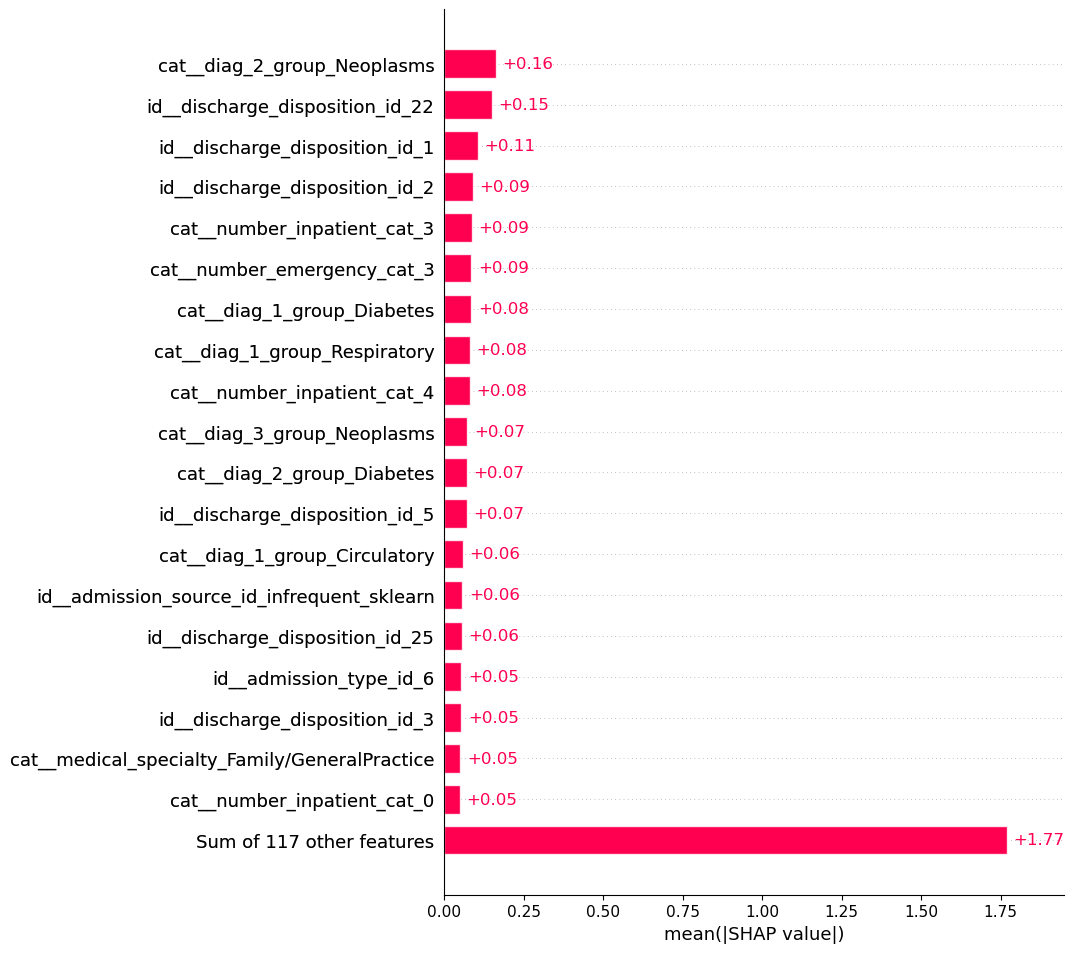

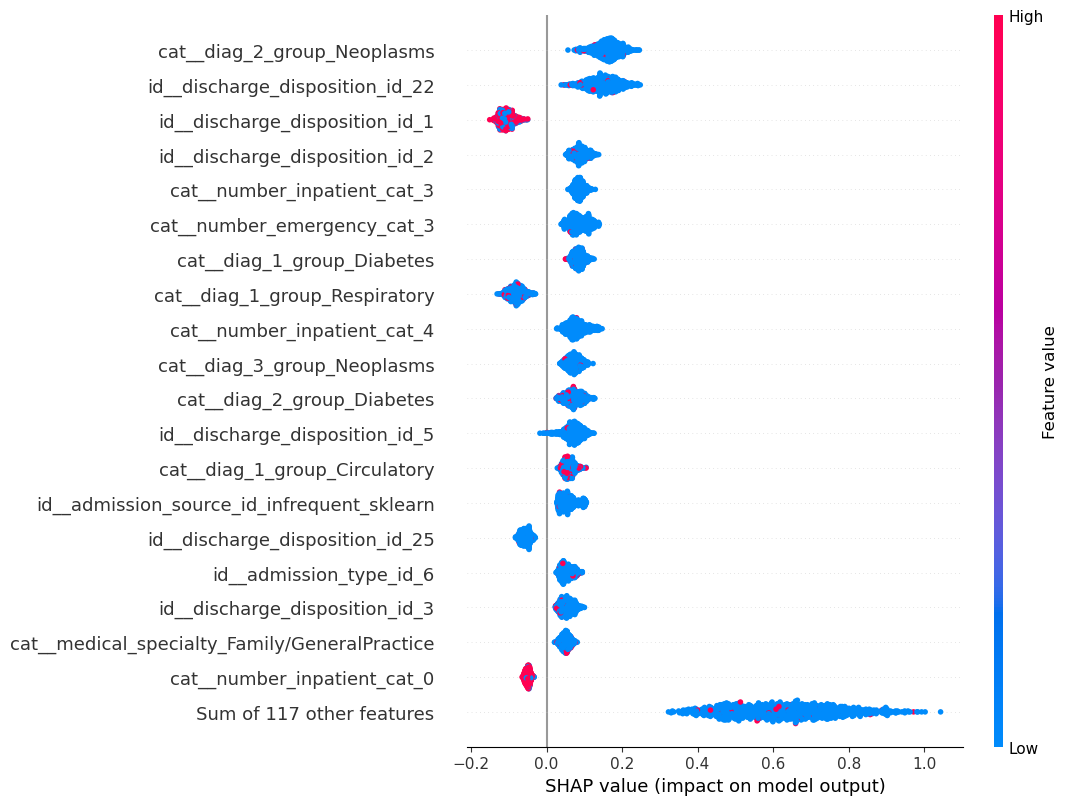

In [115]:
#STAGE 12.5 - GLOBAL SHAP FEATURE IMPORTANCE :
shap.plots.bar(shap_values, max_display=20)
plt.show() #Across the test sample, which transformed variables have the largest average absolute effect on the XGBoost predictions?

#STAGE 12.6 - SHAP BEESWARM PLOT
shap.plots.beeswarm(shap_values, max_display=20)
plt.show() #bar chart shows you importance, but beeswarm shows both direction and imporrtance
#SHAP value > 0 means the feature pushed the prediction toward higher predicted 30-day readmission risk
#<0 means the feature pushed the prediction toward lower predicted risk.

In [116]:
#STAGE 12.7 - SHAP FEATURE IMPORTANCE TABLE

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": X_shap_df.columns,
    "Mean_Absolute_SHAP": mean_abs_shap
})

shap_importance = (
    shap_importance
    .sort_values("Mean_Absolute_SHAP", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 features according to mean absolute SHAP value:")
display(shap_importance.head(20))

Top 20 features according to mean absolute SHAP value:


,Feature,Mean_Absolute_SHAP
0,cat__diag_2_group_Neoplasms,0.162320
1,id__discharge_disposition_id_22,0.149988
2,id__discharge_disposition_id_1,0.106162
3,id__discharge_disposition_id_2,0.089295
4,cat__number_inpatient_cat_3,0.086565
5,cat__number_emergency_cat_3,0.085744
6,cat__diag_1_group_Diabetes,0.084843
7,cat__diag_1_group_Respiratory,0.081322
8,cat__number_inpatient_cat_4,0.079601
9,cat__diag_3_group_Neoplasms,0.072533


In [118]:
#STAGE 12.8 - LOCAL SHAP EXPLANATION FOR ONE HIGH-RISK PATIENT
#ie a patient in the SHAP sample with the highest predicted readmission probability

#Predicted probabilities for patients included in the SHAP sample
shap_sample_proba = final_xgb.predict_proba(X_shap_original)[:, 1]

#Position of highest-risk patient within this sample
highest_risk_position = np.argmax(shap_sample_proba)

highest_risk_probability = shap_sample_proba[highest_risk_position]
highest_risk_index = X_shap_original.index[highest_risk_position]

print("Patient index:", highest_risk_index)

print(f"Predicted probability of 30-day readmission: "
    f"{highest_risk_probability:.3f}")

print(f"Operating threshold: "
    f"{final_threshold:.3f}")

print("Predicted class:",
    int(highest_risk_probability >= final_threshold))

Patient index: 24131
Predicted probability of 30-day readmission: 0.445
Operating threshold: 0.080
Predicted class: 1


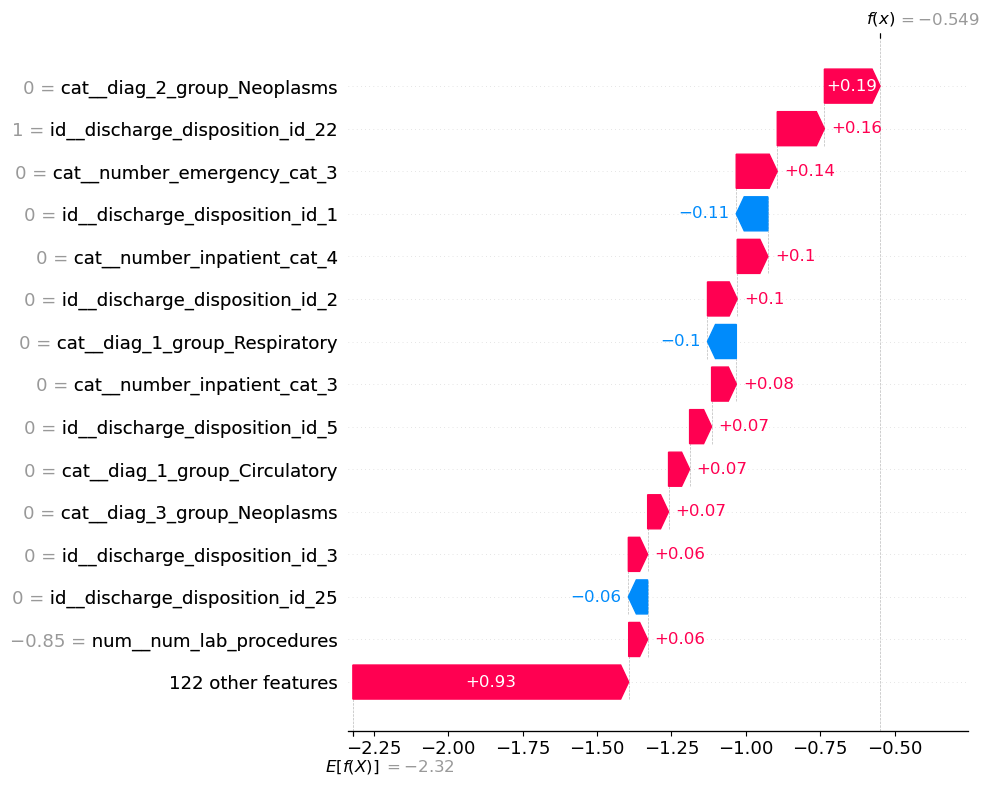

In [119]:
#SHAP WATERFALL PLOT FOR THAT PATIENT

shap.plots.waterfall(
    shap_values[highest_risk_position],
    max_display=15)

plt.show()

In [120]:
#VIEW ORIGINAL VALUES FOR THE EXPLAINED PATIENT

patient_original_values = X_test.loc[[highest_risk_index]]

display(patient_original_values.T)

,24131
race,Caucasian
gender,Male
age,[70-80)
admission_type_id,1
discharge_disposition_id,22
admission_source_id,7
time_in_hospital,2
medical_specialty,Unknown
num_lab_procedures,26
num_procedures,0


Number of true-positive patients in SHAP sample: 60
True-positive patient index: 20007
Predicted readmission probability: 0.093


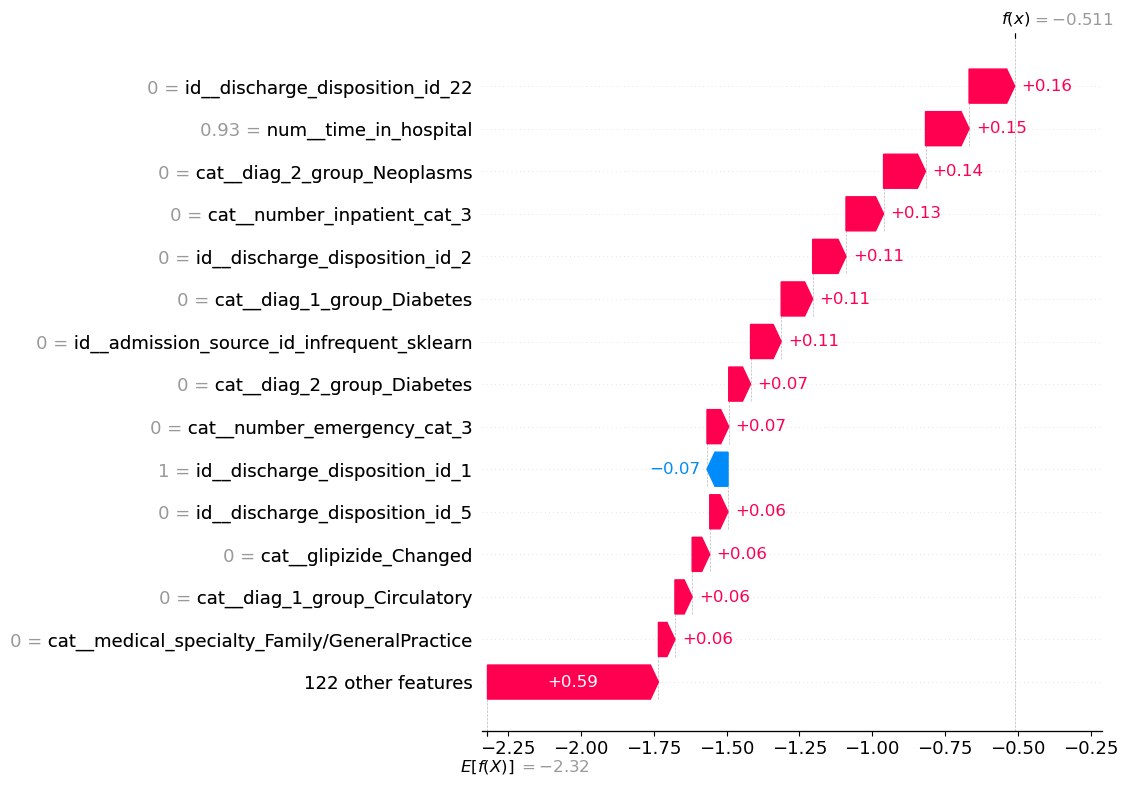

,20007
race,Caucasian
gender,Female
age,[70-80)
admission_type_id,1
discharge_disposition_id,1
admission_source_id,7
time_in_hospital,7
medical_specialty,Unknown
num_lab_procedures,64
num_procedures,0


In [122]:
#STAGE 12.9 - use a true-positive patient for local explanation

#Align true outcomes with SHAP sample
y_shap = y_test.loc[X_shap_original.index]

shap_pred = (
    shap_sample_proba >= final_threshold
).astype(int)

#True positive = actual readmission AND predicted readmission
true_positive_positions = np.where(
    (y_shap.to_numpy() == 1) &
    (shap_pred == 1)
)[0]

print("Number of true-positive patients in SHAP sample:",
      len(true_positive_positions))

if len(true_positive_positions) > 0:
    tp_position = true_positive_positions[0]
    tp_index = X_shap_original.index[tp_position]
    
    print("True-positive patient index:", tp_index)
    print(
        "Predicted readmission probability:",
        round(shap_sample_proba[tp_position], 3)
    )

    shap.plots.waterfall(
        shap_values[tp_position],
        max_display=15
    )

    plt.show()

    display(X_test.loc[[tp_index]].T)

### Partial Dependence Analysis

SHAP describes how features contribute to individual model predictions. A Partial Dependence Plot (PDP) provides a complementary global interpretation by showing the model's average predicted response as one feature changes while averaging over the remaining observations.

PDP results represent relationships learned by the model and should not be interpreted as causal effects.

In [123]:
#STAGE 12.10 - IDENTIFY MOST IMPORTANT NUMERICAL FEATURE

#Names from original numeric feature list
numeric_feature_names = numeric_cols.copy()

numeric_shap_importance = shap_importance[
    shap_importance["Feature"].apply(
        lambda x: any(
            x.endswith(num) or x == f"num__{num}"
            for num in numeric_feature_names)
    )].copy()

display(numeric_shap_importance.head(10))

,Feature,Mean_Absolute_SHAP
20,num__time_in_hospital,0.046648
33,num__num_lab_procedures,0.032949
48,num__num_medications,0.021867
50,num__num_procedures,0.021534
71,num__number_diagnoses,0.013698
72,num__any_number_outpatient,0.013378
85,num__num_med_changes,0.010236


Numerical feature selected for PDP: time_in_hospital


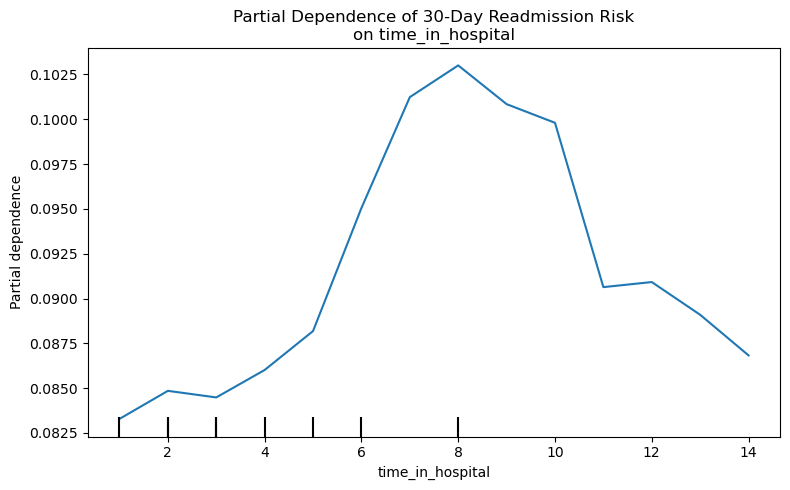

In [124]:
#STAGE 12.11 - PARTIAL DEPENDENCE PLOT
#choose the highest-ranking numerical feature from that table automatically

from sklearn.inspection import PartialDependenceDisplay

#Take highest ranked numerical SHAP feature
top_numeric_transformed = numeric_shap_importance.iloc[0]["Feature"]

#Remove ColumnTransformer prefix, e.g. num__number_inpatient becomes number_inpatient
top_numeric_feature = top_numeric_transformed.replace("num__", "")
print("Numerical feature selected for PDP:", top_numeric_feature)

fig, ax = plt.subplots(figsize=(8, 5))

PartialDependenceDisplay.from_estimator(
    final_xgb,
    X_test,
    features=[top_numeric_feature],
    kind="average",
    ax=ax
)

plt.title(
    f"Partial Dependence of 30-Day Readmission Risk\n"
    f"on {top_numeric_feature}")

plt.tight_layout()
plt.show()

## STAGE 13: BIAS & FAIRNESS ANALYSIS

Because the model may be used to prioritise patients for post-discharge support, model performance should be examined across demographic groups.

The sensitive attributes evaluated are:

- **Race**
- **Gender**
- **Age**

Fairness is assessed on the untouched test set using the final XGBoost model and the operating threshold selected from out-of-fold training predictions.

The analysis considers:

- Observed readmission prevalence
- Model selection / positive prediction rate
- True Positive Rate (Recall)
- False Positive Rate
- False Negative Rate
- Precision
- Specificity
- PR-AUC and ROC-AUC
- Mean predicted risk
- Brier score

Group fairness is additionally summarised using:

- **Demographic parity difference:** difference between the highest and lowest positive prediction rates.
- **Disparate impact ratio:** ratio of the lowest to highest positive prediction rate.
- **Equal opportunity difference:** difference between the highest and lowest true-positive rates.
- **False-positive-rate difference:** difference between the highest and lowest false-positive rates.
- **Equalized odds difference:** the larger of the TPR and FPR differences.

Values closer to zero indicate greater similarity for difference-based measures, while a disparate-impact ratio closer to one indicates more similar selection rates. These metrics should not be interpreted as proof that a model is fair or unfair on their own. Differences can also arise from differences in outcome prevalence, sample size, data quality, healthcare access, or other unobserved factors.

In [125]:
#STAGE 13.1 - FAIRNESS AUDIT FUNCTION

def safe_divide(numerator, denominator):
    """Avoid division-by-zero errors."""
    if denominator == 0:
        return np.nan
    return numerator / denominator


def subgroup_fairness_table(
    group_series,
    group_name,
    y_true,
    y_prob,
    y_pred
):
    """
    Calculate model performance and fairness-related metrics
    separately for each demographic group.
    """

    #Keep the original order of X_test / y_test
    groups = (
        pd.Series(group_series)
        .astype("object")
        .fillna("Missing/Unknown")
        .astype(str)
        .to_numpy()
    )

    audit_df = pd.DataFrame({
        "Group": groups,
        "y_true": np.asarray(y_true).astype(int),
        "y_prob": np.asarray(y_prob),
        "y_pred": np.asarray(y_pred).astype(int)
    })

    rows = []

    for group_value, g in audit_df.groupby("Group"):

        tn, fp, fn, tp = confusion_matrix(
            g["y_true"],
            g["y_pred"],
            labels=[0, 1]
        ).ravel()

        #AUC cannot be calculated when only one true class is prewsent in a subgroup
        if g["y_true"].nunique() == 2:
            roc_auc = roc_auc_score(
                g["y_true"],
                g["y_prob"]
            )
        else:
            roc_auc = np.nan

        #PR-AUC requires at least one positive case
        if g["y_true"].sum() > 0:
            pr_auc = average_precision_score(
                g["y_true"],
                g["y_prob"]
            )
        else:
            pr_auc = np.nan

        rows.append({
            "Sensitive_Feature": group_name,
            "Group": group_value,
            "N": len(g),

            #Base rate
            "Observed_Prevalence":
                g["y_true"].mean(),

            #Probability output
            "Mean_Predicted_Risk":
                g["y_prob"].mean(),

            #Demographic parity / selection rate
            "Selection_Rate":
                g["y_pred"].mean(),

            #Error rates
            "TPR_Recall":
                safe_divide(tp, tp + fn),

            "FPR":
                safe_divide(fp, fp + tn),

            "FNR":
                safe_divide(fn, fn + tp),

            "Precision":
                safe_divide(tp, tp + fp),

            "Specificity":
                safe_divide(tn, tn + fp),

            #Ranking / probability metrics
            "PR_AUC":
                pr_auc,

            "ROC_AUC":
                roc_auc,

            "Brier":
                brier_score_loss(
                    g["y_true"],
                    g["y_prob"]
                )
        })

    result = pd.DataFrame(rows)

    result = (result.sort_values("N", ascending=False).reset_index(drop=True))

    return result

In [126]:
#STAGE 13.2 - FAIRNESS AUDIT BY RACE 

race_fairness = subgroup_fairness_table(
    group_series=X_test["race"],
    group_name="Race",
    y_true=y_test,
    y_prob=test_proba,
    y_pred=test_pred
)

print("FAIRNESS AUDIT BY RACE")

display(race_fairness.round(3))

FAIRNESS AUDIT BY RACE


,Sensitive_Feature,Group,N,Observed_Prevalence,Mean_Predicted_Risk,Selection_Rate,TPR_Recall,FPR,FNR,Precision,Specificity,PR_AUC,ROC_AUC,Brier
0,Race,Caucasian,10509,0.091,0.090,0.468,0.647,0.450,0.353,0.126,0.550,0.184,0.641,0.080
1,Race,AfricanAmerican,2504,0.090,0.084,0.417,0.631,0.396,0.369,0.136,0.604,0.173,0.673,0.079
2,Race,Unknown,364,0.052,0.079,0.379,0.737,0.359,0.263,0.101,0.641,0.239,0.738,0.047
3,Race,Hispanic,299,0.097,0.083,0.381,0.690,0.348,0.310,0.175,0.652,0.233,0.688,0.083
4,Race,Other,231,0.048,0.077,0.359,0.727,0.341,0.273,0.096,0.659,0.242,0.732,0.044
5,Race,Asian,88,0.125,0.081,0.341,0.727,0.286,0.273,0.267,0.714,0.342,0.769,0.104


In [127]:
#STAGE 13.3 - FAIRNESS AUDIT BY GENDER

gender_fairness = subgroup_fairness_table(
    group_series=X_test["gender"],
    group_name="Gender",
    y_true=y_test,
    y_prob=test_proba,
    y_pred=test_pred
)

print("FAIRNESS AUDIT BY GENDER")

display(gender_fairness.round(3))

FAIRNESS AUDIT BY GENDER


,Sensitive_Feature,Group,N,Observed_Prevalence,Mean_Predicted_Risk,Selection_Rate,TPR_Recall,FPR,FNR,Precision,Specificity,PR_AUC,ROC_AUC,Brier
0,Gender,Female,7436,0.089,0.089,0.466,0.660,0.447,0.340,0.126,0.553,0.186,0.657,0.078
1,Gender,Male,6558,0.091,0.087,0.436,0.635,0.417,0.365,0.132,0.583,0.181,0.647,0.080
2,Gender,Missing/Unknown,1,0.000,0.163,1.000,NaN,1.000,NaN,0.000,0.000,NaN,NaN,0.027


In [128]:
#STAGE 13.4 - FAIRNESS AUDIT BY ORIGINAL AGE BAND

age_band_fairness = subgroup_fairness_table(
    group_series=X_test["age"],
    group_name="Age Band",
    y_true=y_test,
    y_prob=test_proba,
    y_pred=test_pred
)

print("FAIRNESS AUDIT BY ORIGINAL AGE BAND")

display(age_band_fairness.round(3))

FAIRNESS AUDIT BY ORIGINAL AGE BAND


,Sensitive_Feature,Group,N,Observed_Prevalence,Mean_Predicted_Risk,Selection_Rate,TPR_Recall,FPR,FNR,Precision,Specificity,PR_AUC,ROC_AUC,Brier
0,Age Band,[70-80),3614,0.105,0.099,0.550,0.747,0.527,0.253,0.142,0.473,0.239,0.660,0.089
1,Age Band,[60-70),3099,0.089,0.088,0.428,0.578,0.414,0.422,0.120,0.586,0.144,0.619,0.080
2,Age Band,[50-60),2485,0.081,0.068,0.248,0.478,0.228,0.522,0.156,0.772,0.169,0.673,0.072
3,Age Band,[80-90),2237,0.101,0.106,0.688,0.797,0.676,0.203,0.118,0.324,0.178,0.635,0.089
4,Age Band,[40-50),1326,0.069,0.074,0.319,0.478,0.307,0.522,0.104,0.693,0.128,0.607,0.064
5,Age Band,[30-40),537,0.058,0.070,0.244,0.484,0.229,0.516,0.115,0.771,0.126,0.699,0.053
6,Age Band,[90-100),360,0.092,0.100,0.656,0.758,0.645,0.242,0.106,0.355,0.227,0.599,0.080
7,Age Band,[20-30),204,0.059,0.075,0.260,0.667,0.234,0.333,0.151,0.766,0.428,0.753,0.047
8,Age Band,[10-20),103,0.049,0.056,0.126,0.400,0.112,0.600,0.154,0.888,0.344,0.790,0.043
9,Age Band,[0-10),30,0.000,0.040,0.033,NaN,0.033,NaN,0.000,0.967,NaN,NaN,0.002


In [130]:
#STAGE 13.5 - CREATE BROADER AGE GROUPS FOR MORE STABLE FAIRNESS ESTIMATES (some age bands only 30 ppl)

age_group_map = {
    "[0-10)": "0-39",
    "[10-20)": "0-39",
    "[20-30)": "0-39",
    "[30-40)": "0-39",

    "[40-50)": "40-59",
    "[50-60)": "40-59",

    "[60-70)": "60-79",
    "[70-80)": "60-79",

    "[80-90)": "80+",
    "[90-100)": "80+"
}

age_fairness_group = (
    X_test["age"]
    .astype("object")
    .map(age_group_map)
    .fillna("Missing/Unknown")
)

print(age_fairness_group.value_counts())

#FAIRNESS AUDIT USING BROADER AGE GROUPS
age_fairness = subgroup_fairness_table(
    group_series=age_fairness_group,
    group_name="Age Group",
    y_true=y_test,
    y_prob=test_proba,
    y_pred=test_pred
)

print("FAIRNESS AUDIT BY BROAD AGE GROUP")
display(age_fairness.round(3))

age
60-79    6713
40-59    3811
80+      2597
0-39      874
Name: count, dtype: int64
FAIRNESS AUDIT BY BROAD AGE GROUP


,Sensitive_Feature,Group,N,Observed_Prevalence,Mean_Predicted_Risk,Selection_Rate,TPR_Recall,FPR,FNR,Precision,Specificity,PR_AUC,ROC_AUC,Brier
0,Age Group,60-79,6713,0.097,0.094,0.494,0.676,0.474,0.324,0.133,0.526,0.196,0.642,0.085
1,Age Group,40-59,3811,0.077,0.070,0.273,0.478,0.256,0.522,0.135,0.744,0.152,0.650,0.069
2,Age Group,80+,2597,0.100,0.106,0.683,0.792,0.671,0.208,0.116,0.329,0.183,0.631,0.087
3,Age Group,0-39,874,0.055,0.069,0.227,0.521,0.209,0.479,0.126,0.791,0.188,0.730,0.049


In [131]:
#STAGE 13.6 - SUMMARY FAIRNESS METRICS
#groups with fewer than 50 observations are not deleted from analysis. They remain in the full tables.
#They are only excluded from the aggregate gap statistic because metrics based on extremely small groups are unstable

def fairness_gap_summary(
    fairness_table,
    feature_name,
    min_group_n=50
):
    """
    Compare group-level fairness metrics.

    Groups with fewer than min_group_n observations remain
    visible in the detailed tables but are excluded from the
    gap calculation because estimates from extremely small
    groups can be unstable.
    """

    eligible = fairness_table[
        fairness_table["N"] >= min_group_n
    ].copy()

    def metric_range(column):
        values = eligible[column].dropna()

        if len(values) < 2:
            return np.nan

        return values.max() - values.min()

    #Demographic parity
    selection_rates = (
        eligible["Selection_Rate"]
        .dropna()
    )

    if (
        len(selection_rates) >= 2
        and selection_rates.max() > 0
    ):
        disparate_impact_ratio = (
            selection_rates.min()
            / selection_rates.max()
        )
    else:
        disparate_impact_ratio = np.nan

    tpr_difference = metric_range("TPR_Recall")
    fpr_difference = metric_range("FPR")

    if (
        pd.notna(tpr_difference)
        and pd.notna(fpr_difference)
    ):
        equalized_odds_difference = max(
            tpr_difference,
            fpr_difference
        )
    else:
        equalized_odds_difference = np.nan

    return {
        "Sensitive_Feature": feature_name,
        "Groups_Included": len(eligible),

        "Demographic_Parity_Difference":
            metric_range("Selection_Rate"),

        "Disparate_Impact_Ratio":
            disparate_impact_ratio,

        "Equal_Opportunity_Difference":
            tpr_difference,

        "FPR_Difference":
            fpr_difference,

        "Equalized_Odds_Difference":
            equalized_odds_difference
    }

In [132]:
#STAGE 13.7 - FINAL FAIRNESS SUMMARY TABLE

fairness_summary = pd.DataFrame([
    fairness_gap_summary(race_fairness, "Race"),
    fairness_gap_summary(gender_fairness, "Gender"),
    fairness_gap_summary(age_fairness, "Age Group")
])

display(fairness_summary.round(3))

,Sensitive_Feature,Groups_Included,Demographic_Parity_Difference,Disparate_Impact_Ratio,Equal_Opportunity_Difference,FPR_Difference,Equalized_Odds_Difference
0,Race,6,0.127,0.728,0.106,0.164,0.164
1,Gender,2,0.030,0.937,0.025,0.030,0.030
2,Age Group,4,0.457,0.331,0.314,0.462,0.462


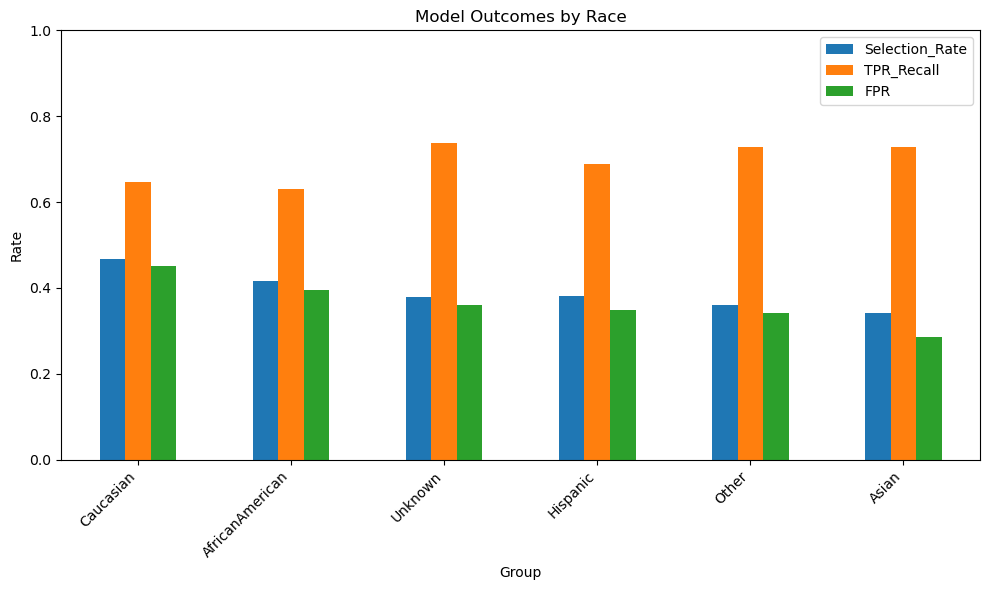

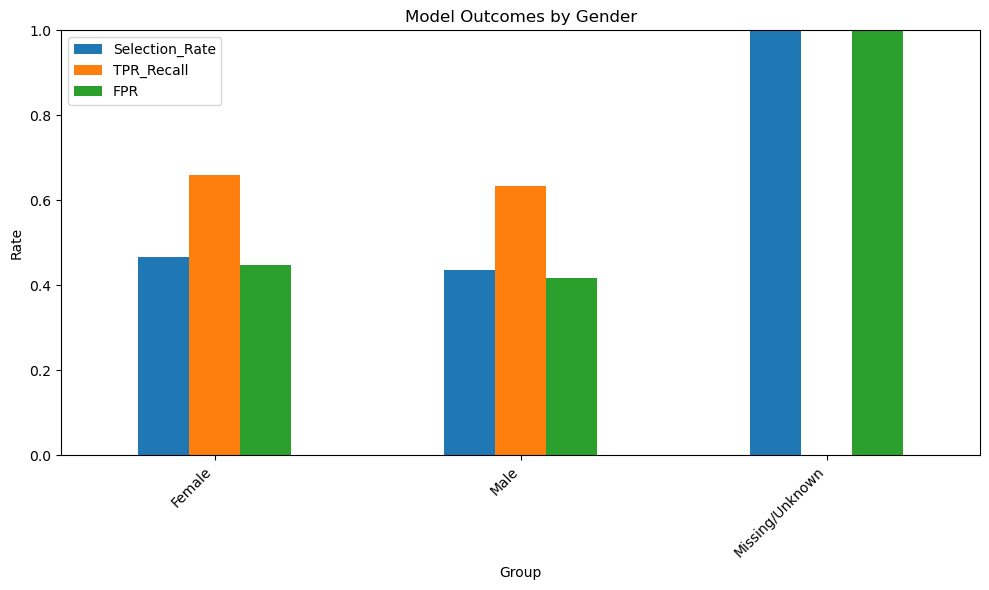

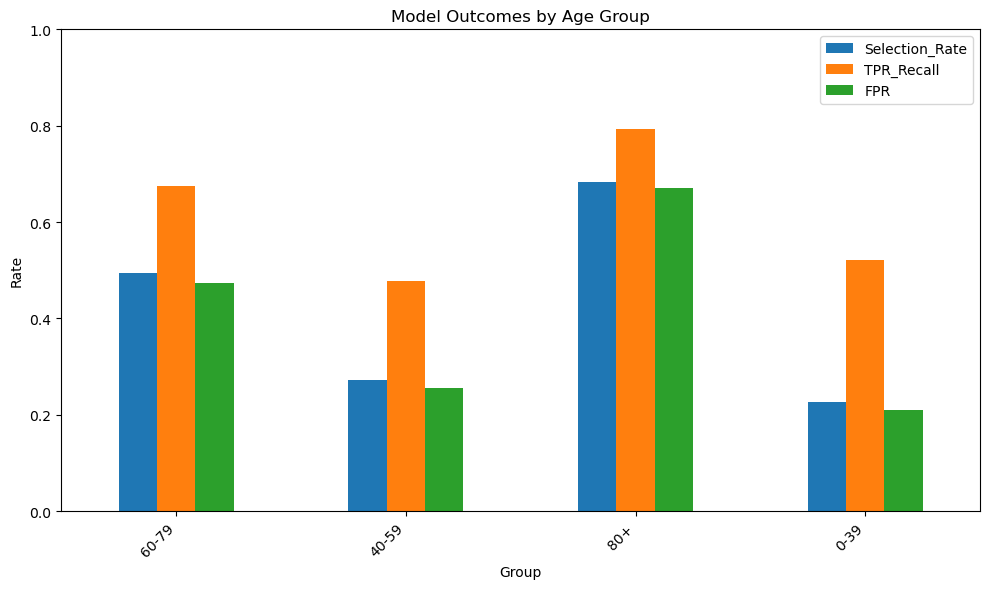

In [133]:
#STAGE 13.8 - VISUALISE FAIRNESS METRICS

def plot_fairness_rates(fairness_table, title):

    plot_data = (
        fairness_table
        .set_index("Group")[
            [
                "Selection_Rate",
                "TPR_Recall",
                "FPR"
            ]
        ]
    )

    ax = plot_data.plot(
        kind="bar",
        figsize=(10, 6)
    )

    ax.set_title(title)
    ax.set_ylabel("Rate")
    ax.set_xlabel("Group")
    ax.set_ylim(0, 1)

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()
    plt.show()


plot_fairness_rates(race_fairness, "Model Outcomes by Race")
plot_fairness_rates(gender_fairness, "Model Outcomes by Gender")
plot_fairness_rates(age_fairness, "Model Outcomes by Age Group")

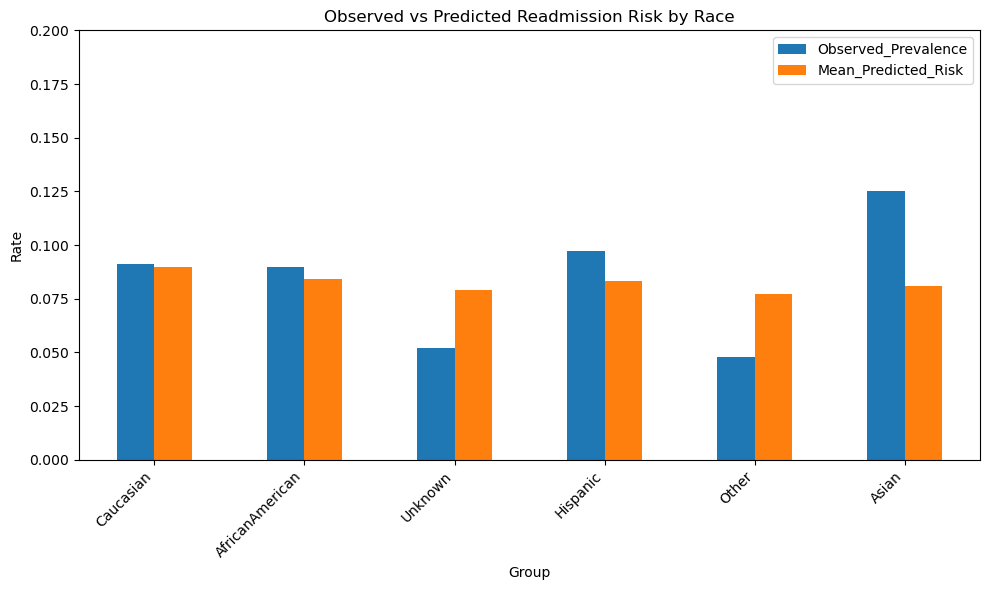

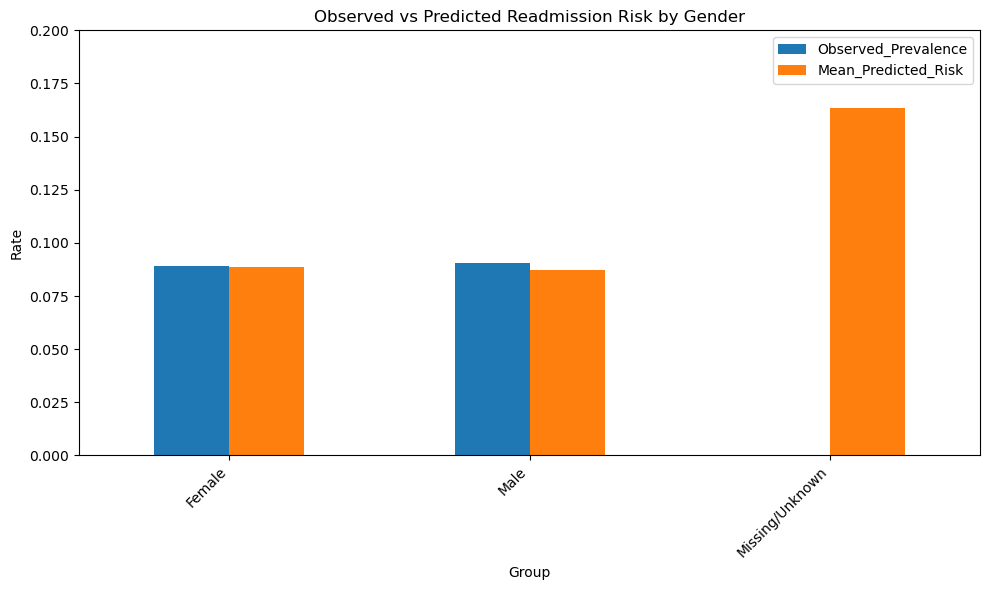

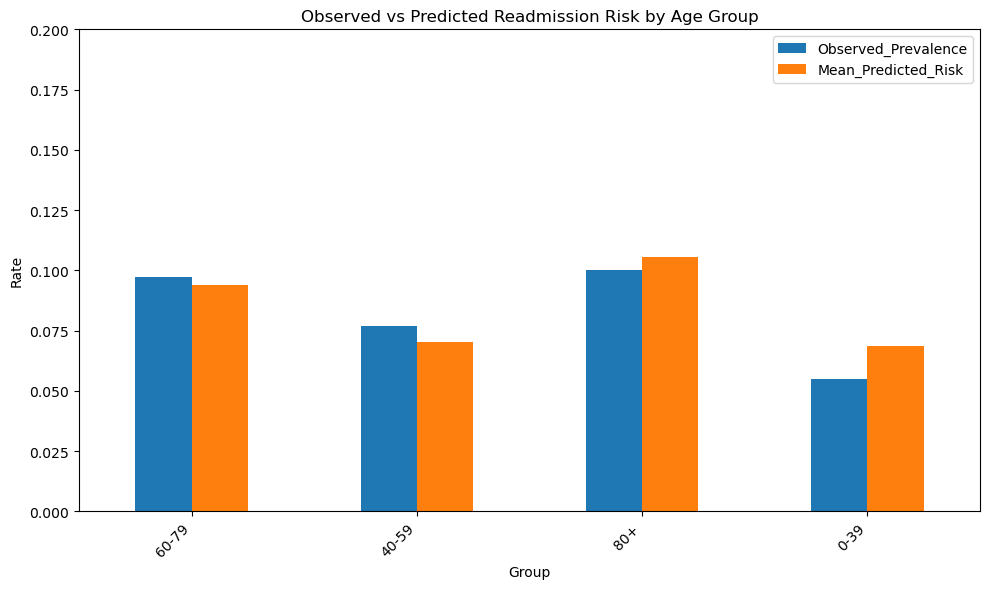

In [134]:
#STAGE 13.9 - COMPARE OBSERVED PREVALENCE WITH MODEL-PREDICTED RISK

def prevalence_vs_prediction_plot(fairness_table, title):

    plot_data = (fairness_table.set_index("Group")[
            ["Observed_Prevalence", "Mean_Predicted_Risk"]
        ]
    )

    ax = plot_data.plot(
        kind="bar",
        figsize=(10, 6)
    )

    ax.set_title(title)
    ax.set_ylabel("Rate")
    ax.set_xlabel("Group")
    ax.set_ylim(0, max(
        0.2,
        plot_data.max().max() * 1.2
    ))

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

prevalence_vs_prediction_plot(race_fairness, "Observed vs Predicted Readmission Risk by Race")
prevalence_vs_prediction_plot(gender_fairness, "Observed vs Predicted Readmission Risk by Gender")
prevalence_vs_prediction_plot(age_fairness, "Observed vs Predicted Readmission Risk by Age Group")

### Sensitive-Attribute Removal Sensitivity Analysis : Does removing race, gender, and age materially change predictive performance or subgroup disparities?

A secondary model is trained using the same selected XGBoost hyperparameters but with race, gender and age removed from the predictors.

This analysis tests whether explicitly excluding sensitive demographic variables materially changes predictive performance or observed subgroup disparities.

Removing protected attributes does not guarantee fairness because other predictors may act as proxies for demographic characteristics. Therefore, subgroup fairness must still be measured after removal.

This model is used as a post-hoc sensitivity analysis only. The held-out test results are not used to retune or select a replacement final model.

In [135]:
#STAGE 13.10 - REMOVE SENSITIVE ATTRIBUTES

from sklearn.base import clone

sensitive_cols = ["race", "gender", "age"]
X_train_no_sensitive = X_train.drop(columns=sensitive_cols, errors="ignore")
X_test_no_sensitive = X_test.drop(columns=sensitive_cols, errors="ignore")


print("Original number of predictors:", X_train.shape[1])
print("Predictors after removing race/gender/age:", X_train_no_sensitive.shape[1])

Original number of predictors: 33
Predictors after removing race/gender/age: 30


In [136]:
#STAGE 13.11 - REBUILD PREPROCESSOR WITHOUT SENSITIVE FEATURES 

numeric_cols_no_sensitive = [
    col for col in numeric_cols
    if col in X_train_no_sensitive.columns
]

categorical_cols_no_sensitive = [
    col for col in categorical_cols
    if col in X_train_no_sensitive.columns
]

id_cat_cols_no_sensitive = [
    col for col in id_cat_cols
    if col in X_train_no_sensitive.columns
]


preprocessor_no_sensitive = ColumnTransformer(
    transformers=[
        ("num",
            clone(numeric_transformer),
            numeric_cols_no_sensitive
        ),
        ("cat",
            clone(categorical_transformer),
            categorical_cols_no_sensitive
        ),
        ("id",
            clone(id_catcol_transformer),
            id_cat_cols_no_sensitive
        )])


no_sensitive_xgb = Pipeline([
    ("preprocessing", preprocessor_no_sensitive),
    ("model", clone(final_xgb.named_steps["model"]))
])


print("Sensitivity-analysis pipeline created.")
#we are not tuning XGBOOST again, we preserved hyperparams of final model

Sensitivity-analysis pipeline created.


In [137]:
#STAGE 13.12 - OOF PREDICTIONS FOR NO-SENSITIVE-ATTRIBUTE MODEL - not using 0.08 automatically. New model may produce probabilities on different scale
#so we determine threshod from training oof predictions like before
no_sensitive_oof_proba = cross_val_predict(
    no_sensitive_xgb,
    X_train_no_sensitive,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

no_sensitive_threshold, no_sensitive_threshold_df = (
    find_best_threshold(
        y_train,
        no_sensitive_oof_proba
    )
)

print("OOF-selected threshold without sensitive attributes:", round(no_sensitive_threshold, 4))

OOF-selected threshold without sensitive attributes: 0.08


In [139]:
#STAGE 13.13 - FIT SENSITIVITY MODEL AND EVALUATE ON TEST SET

no_sensitive_xgb.fit(X_train_no_sensitive, y_train)

no_sensitive_test_proba = (
    no_sensitive_xgb.predict_proba(
        X_test_no_sensitive
    )[:, 1]
)

no_sensitive_test_pred = (
    no_sensitive_test_proba
    >= no_sensitive_threshold
).astype(int)


no_sensitive_test_metrics = evaluate_model(
    y_test,
    no_sensitive_test_proba,
    no_sensitive_test_pred
)

print("Test performance WITHOUT race, gender and age:")
display(pd.Series(no_sensitive_test_metrics).round(3))

#STAGE 13.14 - PERFORMANCE SENSITIVITY COMPARISON
sensitive_attribute_comparison = pd.DataFrame({
    "Original Final XGBoost": test_metrics,
    "XGBoost Without Race/Gender/Age": pd.Series(no_sensitive_test_metrics)
})

display(sensitive_attribute_comparison.round(3))

Test performance WITHOUT race, gender and age:


ROC_AUC              0.652
PR_AUC               0.177
Recall               0.641
Precision            0.129
Specificity          0.574
F1                   0.215
Balanced_accuracy    0.608
Brier                0.079
dtype: float64

,Original Final XGBoost,XGBoost Without Race/Gender/Age
ROC_AUC,0.652,0.652
PR_AUC,0.182,0.177
Recall,0.648,0.641
Precision,0.128,0.129
Specificity,0.567,0.574
F1,0.214,0.215
Balanced_accuracy,0.607,0.608
Brier,0.079,0.079


In [140]:
#STAGE 13.15 - FAIRNESS AFTER REMOVING SENSITIVE ATTRIBUTES (removing columns dont make it automatically fair)

race_fairness_no_sensitive = subgroup_fairness_table(
    group_series=X_test["race"],
    group_name="Race",
    y_true=y_test,
    y_prob=no_sensitive_test_proba,
    y_pred=no_sensitive_test_pred
)

gender_fairness_no_sensitive = subgroup_fairness_table(
    group_series=X_test["gender"],
    group_name="Gender",
    y_true=y_test,
    y_prob=no_sensitive_test_proba,
    y_pred=no_sensitive_test_pred
)

age_fairness_no_sensitive = subgroup_fairness_table(
    group_series=age_fairness_group,
    group_name="Age Group",
    y_true=y_test,
    y_prob=no_sensitive_test_proba,
    y_pred=no_sensitive_test_pred
)

no_sensitive_fairness_summary = pd.DataFrame([
    fairness_gap_summary(race_fairness_no_sensitive, "Race"),
    fairness_gap_summary(gender_fairness_no_sensitive, "Gender"),
    fairness_gap_summary(age_fairness_no_sensitive, "Age Group")
])

display(no_sensitive_fairness_summary.round(3))

,Sensitive_Feature,Groups_Included,Demographic_Parity_Difference,Disparate_Impact_Ratio,Equal_Opportunity_Difference,FPR_Difference,Equalized_Odds_Difference
0,Race,6,0.117,0.744,0.158,0.141,0.158
1,Gender,2,0.040,0.914,0.042,0.040,0.042
2,Age Group,4,0.418,0.343,0.237,0.422,0.422


In [141]:
#STAGE 13.16 - ORIGINAL VS NO-SENSITIVE-ATTRIBUTES FAIRNESS

original_summary = fairness_summary.copy()
original_summary.insert(
    0,
    "Model",
    "Original XGBoost"
)

no_sensitive_summary = (no_sensitive_fairness_summary.copy())

no_sensitive_summary.insert(
    0,
    "Model",
    "Without Race/Gender/Age"
)

fairness_model_comparison = pd.concat(
    [original_summary, no_sensitive_summary],
    ignore_index=True
)

display(fairness_model_comparison.round(3))

,Model,Sensitive_Feature,Groups_Included,Demographic_Parity_Difference,Disparate_Impact_Ratio,Equal_Opportunity_Difference,FPR_Difference,Equalized_Odds_Difference
0,Original XGBoost,Race,6,0.127,0.728,0.106,0.164,0.164
1,Original XGBoost,Gender,2,0.030,0.937,0.025,0.030,0.030
2,Original XGBoost,Age Group,4,0.457,0.331,0.314,0.462,0.462
3,Without Race/Gender/Age,Race,6,0.117,0.744,0.158,0.141,0.158
4,Without Race/Gender/Age,Gender,2,0.040,0.914,0.042,0.040,0.042
5,Without Race/Gender/Age,Age Group,4,0.418,0.343,0.237,0.422,0.422


In [102]:
#SAVE FINAL XGBOOST MODEL + OPERATING THRESHOLD
import os
import joblib

os.makedirs("models", exist_ok=True)

final_artifact = {
    "model": final_xgb,
    "threshold": final_threshold,   
    "primary_metric": "average_precision",
    "threshold_method": "Youden_J_from_OOF_predictions",
    "best_params": xgb_search.best_params_,
    "random_state": 42
}

artifact_path = "models/final_xgboost_model_and_threshold.joblib"

joblib.dump(final_artifact, artifact_path)

print(f"Final model artefact saved to: {artifact_path}")


#VERIFY SAVED ARTEFACT
loaded_artifact = joblib.load(artifact_path)
loaded_model = loaded_artifact["model"]
loaded_threshold = loaded_artifact["threshold"]

#Small prediction check to confirm successful reload
verification_proba = loaded_model.predict_proba(X_test.iloc[:5])[:, 1]
verification_pred = (verification_proba >= loaded_threshold).astype(int)

print("\nArtefact successfully reloaded.")
print(f"Saved threshold: {loaded_threshold:.4f}")
print("Verification predictions:", verification_pred)

Final model artefact saved to: models/final_xgboost_model_and_threshold.joblib

Artefact successfully reloaded.
Saved threshold: 0.0800
Verification predictions: [1 0 1 1 1]
